# Attempt of validation
1) load the csv.file
2) check, whether we find the two genes tested with CRISPRi (shha, meis1b) in the data sets


shha = (pectoral) fin development, 
meis1b = essential for hematopoiesis

In [184]:
#load the csv.file ( from https://doi.org/10.1093/nar/gkaf1367)
import pandas as pd
val_data = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Validation/gene_table.csv")

# Read the GTF file (from https://ftp.ensembl.org/pub/release-116/gtf/danio_rerio/)
gtf = pd.read_csv("/home/fgsasse_lrs_1/Downloads/Danio_rerio.GRCz11.116.chr.gtf.gz",
    sep="\t",
    comment="#",
    header=None,
    names=[
        "seqname", "source", "feature", "start", "end",
        "score", "strand", "frame", "attribute"
    ],
    compression="gzip"
)

print(gtf.head())

  seqname  source     feature     start       end score strand frame  \
0       4  havana        gene  30402837  30403763     .      +     .   
1       4  havana  transcript  30402837  30403763     .      +     .   
2       4  havana        exon  30402837  30402893     .      +     .   
3       4  havana        exon  30403203  30403350     .      +     .   
4       4  havana        exon  30403546  30403763     .      +     .   

                                           attribute  
0  gene_id "ENSDARG00000103202"; gene_version "2"...  
1  gene_id "ENSDARG00000103202"; gene_version "2"...  
2  gene_id "ENSDARG00000103202"; gene_version "2"...  
3  gene_id "ENSDARG00000103202"; gene_version "2"...  
4  gene_id "ENSDARG00000103202"; gene_version "2"...  


/tmp/ipykernel_4052676/552678994.py:6: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  gtf = pd.read_csv("/home/fgsasse_lrs_1/Downloads/Danio_rerio.GRCz11.116.chr.gtf.gz",


In [185]:
val_data.head()

,Chr,Promoter_start,Promoter_end,Enhancer_start,Enhancer_end,Dist_kb,target_gene_ID
0,1,2300000,2325000,2400000,2425000,100.0,ENSDARG00000040245
1,1,2400000,2425000,2300000,2325000,100.0,ENSDARG00000074381
2,1,7550000,7575000,7650000,7675000,100.0,ENSDARG00000017441
3,1,7650000,7675000,7550000,7575000,100.0,ENSDARG00000018319
4,1,8700000,8725000,8900000,8925000,200.0,ENSDARG00000012458


In [186]:
#find the gene_id for the gene_name "shha" and "meis1b"
genes = gtf[gtf["feature"] == "gene"].copy()

genes["gene_id"] = genes["attribute"].str.extract(r'gene_id "([^"]+)"')
genes["gene_name"] = genes["attribute"].str.extract(r'gene_name "([^"]+)"')

gene_name = genes.loc[
    genes["gene_name"] == "shha"
    "",
    "gene_id"
]

print(gene_name.iloc[0] if len(gene_name) else "Not found")

gene_name = genes.loc[
    genes["gene_name"] == "meis1b",
    "gene_id"
]

print(gene_name.iloc[0] if len(gene_name) else "Not found")


ENSDARG00000068567
ENSDARG00000012078


In [187]:
#check if these gene_ids are present in the val_data dataframe
shha_gene_id = "ENSDARG00000068567"
meis1b_gene_id = "ENSDARG00000012078"

val_data[val_data["target_gene_ID"].isin([meis1b_gene_id])].head()

,Chr,Promoter_start,Promoter_end,Enhancer_start,Enhancer_end,Dist_kb,target_gene_ID
230,13,5560000,5570000,5490000,5500000,70.0,ENSDARG00000012078


In [188]:
#create a list for the gene meis1b with its peaks


# Filter for meis1b
meis1b_df = val_data[val_data["target_gene_ID"] == "ENSDARG00000012078"].copy()

# Create promoter and enhancer peak IDs
meis1b_df["promoter_peak_id"] = (
    meis1b_df["Chr"].astype(str) + "-" +
    meis1b_df["Promoter_start"].astype(str) + "-" +
    meis1b_df["Promoter_end"].astype(str)
)

meis1b_df["enhancer_peak_id"] = (
    meis1b_df["Chr"].astype(str) + "-" +
    meis1b_df["Enhancer_start"].astype(str) + "-" +
    meis1b_df["Enhancer_end"].astype(str)
)

# Display the result
print(meis1b_df[[
    "target_gene_ID",
    "promoter_peak_id",
    "enhancer_peak_id"
]])

         target_gene_ID    promoter_peak_id    enhancer_peak_id
230  ENSDARG00000012078  13-5560000-5570000  13-5490000-5500000


In [ ]:
#add a gene_name column to the meis1b_df
meis1b_df["gene"] = "meis1b"
meis1b_df.head()

,Chr,Promoter_start,Promoter_end,Enhancer_start,Enhancer_end,Dist_kb,target_gene_ID,promoter_peak_id,enhancer_peak_id,gene
230,13,5560000,5570000,5490000,5500000,70.0,ENSDARG00000012078,13-5560000-5570000,13-5490000-5500000,meis1b


In [189]:
#list of peaks for meis1b with gene name "meis1b" 
gene_peak_dict = {
    "meis1b": list(
        pd.unique(
            meis1b_df[["promoter_peak_id", "enhancer_peak_id"]].values.ravel()
        )
    )
}

# Loading results

In [204]:
#read in the saved all_ols_dfs dataframe of ct + time
import pandas as pd
ols_res_df_ctt = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_res_all_windows_range_df_ct_time.csv")
ols_res_100kb_ctt = ols_res_df_ctt[ols_res_df_ctt["window"] == "100kb"].copy()
ols_res_100kb_ctt.head()

ols_res_df_sc = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_results_100kb_df_sc.csv")
ols_res_100kb_sc = ols_res_df_sc[ols_res_df_sc["window"] == "100kb"].copy()
ols_res_100kb_sc.head()

,window,gene,peak,coef,pval,category
0,100kb,a1cf,12-6186644-6187111,0.021198,0.056007,non-significant
1,100kb,a1cf,12-6190483-6191143,0.018545,0.063436,non-significant
2,100kb,a1cf,12-6225169-6226018,-0.005018,0.621363,non-significant
3,100kb,a1cf,12-6114452-6114950,-0.001729,0.865097,non-significant
4,100kb,a1cf,12-6140521-6140735,-0.013947,0.155559,non-significant


In [205]:
##read in the results from correlation analysis, then aggregate
import pandas as pd

cor_res_100kb_ctt = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Results/gene_peak_correlation_ct_time_100kb_results.csv")
print(cor_res_100kb_ctt.head())
cor_100kb_df_sc = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Results/gene_peak_correlation_sc_100kb_results.csv")
print(cor_100kb_df_sc.head())

# classify every peak–gene pair into one of three categories
def classify_pair(row):
    if row["padj"] <= 0.05 and row["correlation"] < 0:
        return "sig. negative"
    elif row["padj"] <= 0.05 and row["correlation"] > 0:
        return "sig. positive"
    else:
        return "non-significant"



cor_res_100kb_ctt["category"] = cor_res_100kb_ctt.apply(classify_pair, axis=1)
cor_100kb_df_sc["category"] = cor_100kb_df_sc.apply(classify_pair, axis=1)

  window  gene                peak  correlation    pvalue  neglog10_pvalue  \
0  100kb  a1cf  12-6186644-6187111     0.193512  0.006576         2.182015   
1  100kb  a1cf  12-6190483-6191143     0.135734  0.057840         1.237772   
2  100kb  a1cf  12-6225169-6226018     0.080739  0.260606         0.584015   
3  100kb  a1cf  12-6114452-6114950     0.125358  0.079997         1.096924   
4  100kb  a1cf  12-6140521-6140735     0.040975  0.568525         0.245251   

       padj  neglog10_padj  
0  0.034600       1.460927  
1  0.173677       0.760259  
2  0.472269       0.325810  
3  0.217494       0.662553  
4  0.748452       0.125836  
  window  gene                peak  correlation    pvalue  neglog10_pvalue  \
0  100kb  a1cf  12-6186644-6187111     0.121149  0.000016         4.791006   
1  100kb  a1cf  12-6190483-6191143     0.117048  0.000031         4.506702   
2  100kb  a1cf  12-6225169-6226018     0.061143  0.029989         1.523041   
3  100kb  a1cf  12-6114452-6114950     0.0603

In [206]:
#find the gene_id for "meis1b" in correlation results and filter for significant peaks
peaks_cor_ctt = cor_res_100kb_ctt[(cor_res_100kb_ctt["gene"] == "meis1b") & (cor_res_100kb_ctt["category"].isin(["sig. negative", "sig. positive"]))]
peaks_cor_sc = cor_100kb_df_sc[(cor_100kb_df_sc["gene"] == "meis1b") & (cor_100kb_df_sc["category"].isin(["sig. negative", "sig. positive"]))]

#find the gene "meis1b" in the ols results and filter for significant peaks
peaks_ols_ctt = ols_res_100kb_ctt[(ols_res_100kb_ctt["gene"] == "meis1b") & (ols_res_100kb_ctt["category"].isin(["sig. negative", "sig. positive"]))]
peaks_ols_sc = ols_res_100kb_sc[(ols_res_100kb_sc["gene"] == "meis1b") & (ols_res_100kb_sc["category"].isin(["sig. negative", "sig. positive"]))]


#print the number of significant peaks for meis1b in correlation and ols results
print("Number of significant peaks for meis1b in correlation results (ct + time):", len(peaks_cor_ctt))
print("Number of significant peaks for meis1b in correlation results (SEACells):", len(peaks_cor_sc))
print("Number of significant peaks for meis1b in ols results (ct + time):", len(peaks_ols_ctt))
print("Number of significant peaks for meis1b in ols results (SEACells):", len(peaks_ols_sc))

Number of significant peaks for meis1b in correlation results (ct + time): 63
Number of significant peaks for meis1b in correlation results (SEACells): 91
Number of significant peaks for meis1b in ols results (ct + time): 0
Number of significant peaks for meis1b in ols results (SEACells): 20


In [207]:
#keep for each set of peaks only those that are overlapping with the validation data peaks for meis1b
import pandas as pd

def split_peak(df, col="peak"):
    tmp = df[col].str.split("-", expand=True)
    df["chr"] = tmp[0]
    df["start"] = tmp[1].astype(int)
    df["end"] = tmp[2].astype(int)
    return df


In [208]:
#define a function to find overlaps between two dataframes of peaks
def find_overlaps(pred, val):
    overlaps = []

    for _, p in pred.iterrows():
        hits = val[
            (val["chr"] == p["chr"]) &
            (val["start"] <= p["end"]) &
            (val["end"] >= p["start"])
        ]

        if not hits.empty:
            for _, v in hits.iterrows():
                overlaps.append({
                    "selected_peak": f'{p["chr"]}-{p["start"]}-{p["end"]}',
                    "val_peak": f'{v["chr"]}-{v["start"]}-{v["end"]}'
                })

    return pd.DataFrame(overlaps)

Overlapping peaks in CORRELATION results

In [209]:
val_data = split_peak(pd.DataFrame({"peak": gene_peak_dict["meis1b"]}), "peak")

peaks_cor_ctt = split_peak(peaks_cor_ctt.copy(), "peak")
peaks_cor_sc = split_peak(peaks_cor_sc.copy(), "peak")

overlap_cor_ctt = find_overlaps(peaks_cor_ctt, val_data)
overlap_cor_sc = find_overlaps(peaks_cor_sc, val_data)

#add a column to see the type of overlap (promoter or enhancer) for the overlapping peaks
def classify_overlap(row):
    if row["val_peak"] in meis1b_df["promoter_peak_id"].values:
        return "promoter"
    elif row["val_peak"] in meis1b_df["enhancer_peak_id"].values:
        return "enhancer"
    else:
        return "unknown"

overlap_cor_ctt["overlap_type"] = overlap_cor_ctt.apply(classify_overlap, axis=1)
overlap_cor_sc["overlap_type"] = overlap_cor_sc.apply(classify_overlap, axis=1)

print("Overlapping peaks for correlation analysis (ct + time):")
print(overlap_cor_ctt.groupby("overlap_type").size().reset_index(name="count"))
print("\nOverlapping peaks for correlation analysis (single-cell):")
print(overlap_cor_sc.groupby("overlap_type").size().reset_index(name="count"))

Overlapping peaks for correlation analysis (ct + time):
  overlap_type  count
0     enhancer      8
1     promoter      3

Overlapping peaks for correlation analysis (single-cell):
  overlap_type  count
0     enhancer      8
1     promoter      5


Overlapping peaks in OLS results

In [210]:
val_data = split_peak(pd.DataFrame({"peak": gene_peak_dict["meis1b"]}), "peak")

#peaks_ols_ctt = split_peak(peaks_ols_ctt.copy(), "peak")
peaks_ols_sc = split_peak(peaks_ols_sc.copy(), "peak")

#overlap_ols_ctt = find_overlaps(peaks_ols_ctt, val_data)
overlap_ols_sc = find_overlaps(peaks_ols_sc, val_data)

#add a column to see the type of overlap (promoter or enhancer) for the overlapping peaks
def classify_overlap(row):
    if row["val_peak"] in meis1b_df["promoter_peak_id"].values:
        return "promoter"
    elif row["val_peak"] in meis1b_df["enhancer_peak_id"].values:
        return "enhancer"
    else:
        return "unknown"

#overlap_ols_ctt["overlap_type"] = overlap_ols_ctt.apply(classify_overlap, axis=1)
overlap_ols_sc["overlap_type"] = overlap_ols_sc.apply(classify_overlap, axis=1)

#print("Overlapping peaks for correlation analysis (ct + time):")
#print(overlap_ols_ctt.groupby("overlap_type").size().reset_index(name="count"))
print("\nOverlapping peaks for correlation analysis (single-cell):")
print(overlap_ols_sc.groupby("overlap_type").size().reset_index(name="count"))


Overlapping peaks for correlation analysis (single-cell):
  overlap_type  count
0     enhancer      2
1     promoter      1


Merging the overlapping peaks with the ols & cor results to see the percentage

In [221]:
#now we want to check how many of the significant peaks for meis1b in the correlation results are overlapping with the validation data peaks for meis1b
cor_meis1b_ctt = cor_res_100kb_ctt[
    (cor_res_100kb_ctt["gene"] == "meis1b") &
    (cor_res_100kb_ctt["category"].isin(["sig. negative", "sig. positive"]))
].copy()

cor_meis1b_ctt = cor_meis1b_ctt.merge(
    overlap_cor_ctt[["selected_peak", "overlap_type"]],
    left_on="peak",
    right_on="selected_peak",
    how="left"
)

cor_meis1b_ctt["overlap_type"] = cor_meis1b_ctt["overlap_type"].fillna("unvalidated")
cor_meis1b_ctt = cor_meis1b_ctt.drop(columns="selected_peak")

print(cor_meis1b_ctt.groupby("overlap_type").size().reset_index(name="count"))

cor_meis1b_sc = cor_100kb_df_sc[
    (cor_100kb_df_sc["gene"] == "meis1b") &
    (cor_100kb_df_sc["category"].isin(["sig. negative", "sig. positive"]))
].copy()    

cor_meis1b_sc = cor_meis1b_sc.merge(
    overlap_cor_sc[["selected_peak", "overlap_type"]],
    left_on="peak",
    right_on="selected_peak",
    how="left"
)

cor_meis1b_sc["overlap_type"] = cor_meis1b_sc["overlap_type"].fillna("unvalidated")
cor_meis1b_sc = cor_meis1b_sc.drop(columns="selected_peak")

print(cor_meis1b_sc.groupby("overlap_type").size().reset_index(name="count"))

  overlap_type  count
0     enhancer      8
1     promoter      3
2  unvalidated     52
  overlap_type  count
0     enhancer      8
1     promoter      5
2  unvalidated     78


In [222]:
#now we want to check how many of the significant peaks for meis1b in the ols results are overlapping with the validation data peaks for meis1b

ols_meis1b_sc = ols_res_100kb_sc[
    (ols_res_100kb_sc["gene"] == "meis1b") &
    (ols_res_100kb_sc["category"].isin(["sig. negative", "sig. positive"]))
].copy()

ols_meis1b_sc = ols_meis1b_sc.merge(
    overlap_ols_sc[["selected_peak", "overlap_type"]],
    left_on="peak",
    right_on="selected_peak",
    how="left"
)

ols_meis1b_sc["overlap_type"] = ols_meis1b_sc["overlap_type"].fillna("unvalidated")
ols_meis1b_sc = ols_meis1b_sc.drop(columns="selected_peak")

print(ols_meis1b_sc.groupby("overlap_type").size().reset_index(name="count"))

  overlap_type  count
0     enhancer      2
1     promoter      1
2  unvalidated     17


In [223]:
#create a dataframe with one column for the whole count of the sig. peaks, one column for each overlap type (promoter, enhancer, no overlap) and one column for the total count of the overlapping peaks
cor_meis1b_ctt_summary = cor_meis1b_ctt.groupby("overlap_type").size().reset_index(name="count")
cor_meis1b_ctt_summary["total_count"] = cor_meis1b_ctt.groupby("overlap_type").size().sum()
cor_meis1b_ctt_summary["percentage"] = cor_meis1b_ctt_summary["count"] / cor_meis1b_ctt_summary["total_count"] * 100
print(cor_meis1b_ctt_summary.head())

cor_meis1b_sc_summary = cor_meis1b_sc.groupby("overlap_type").size().reset_index(name="count")
cor_meis1b_sc_summary["total_count"] = cor_meis1b_sc.groupby("overlap_type").size().sum()
cor_meis1b_sc_summary["percentage"] = cor_meis1b_sc_summary["count"] / cor_meis1b_sc_summary["total_count"] * 100   
cor_meis1b_sc_summary.head()

  overlap_type  count  total_count  percentage
0     enhancer      8           63   12.698413
1     promoter      3           63    4.761905
2  unvalidated     52           63   82.539683


,overlap_type,count,total_count,percentage
0,enhancer,8,91,8.791209
1,promoter,5,91,5.494505
2,unvalidated,78,91,85.714286


In [ ]:
#create a dataframe with one column for the whole count of the sig. peaks, one column for each overlap type (promoter, enhancer, no overlap) and one column for the total count of the overlapping peaks
ols_meis1b_sc_summary = ols_meis1b_sc.groupby("overlap_type").size().reset_index(name="count")
ols_meis1b_sc_summary["total_count"] = ols_meis1b_sc.groupby("overlap_type").size().sum()
ols_meis1b_sc_summary["percentage"] = ols_meis1b_sc_summary["count"] / ols_meis1b_sc_summary["total_count"] * 100
ols_meis1b_sc_summary.head()

#create a dataframe with one column for the whole count of the sig. peaks, one column for each overlap type (promoter, enhancer, unvalidated) and one column for the total count of the overlapping peaks, besides everything is zero
ols_meis1b_ctt_summary = pd.DataFrame({
    "overlap_type": ["promoter", "enhancer", "unvalidated"],
    "count": [0, 0, 0],
    "total_count": [0, 0, 0],
    "percentage": [0, 0, 0]
})

ols_meis1b_ctt_summary.head()


,overlap_type,count,total_count,percentage
0,promoter,0,0,0
1,enhancer,0,0,0
2,unvalidated,0,0,0


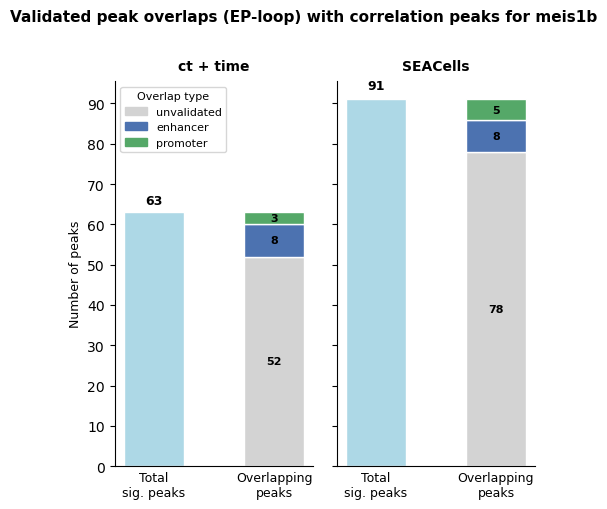

In [224]:
#stacked bar plot of the results of the correlation analysis for meis1b with the validation data peaks for meis1b

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── palette ──────────────────────────────────────────────────────────────────
overlap_colors = {
    "enhancer":    "#4C72B0",
    "promoter":  "#55A868",
    "unvalidated":     "lightgrey",
}
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

def get_color(overlap_type, idx):
    return overlap_colors.get(overlap_type, default_colors[idx % len(default_colors)])

def annotate_bar(ax, x, y_bottom, height, total, fontsize=8):
    """Annotate a bar segment: count + percentage of total."""
    if height == 0:
        return
    label = f"{int(height)}"
    ax.text(x, y_bottom + height / 2, label,
            ha="center", va="center", fontsize=fontsize,
            color="black", fontweight="bold")

# ── plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(5, 5), sharey=True)
titles    = ["ct + time", "SEACells"]
summaries = [cor_meis1b_ctt_summary, cor_meis1b_sc_summary]
# ── fixed stack order ─────────────────────────────────────────────────────────
stack_order = ["unvalidated", "enhancer", "promoter"]
x_total    = 0
x_overlap  = 0.7          # decrease this to close the gap (try 0.5–0.8)
bar_width  = 0.1
for ax, summary, title in zip(axes, summaries, titles):
    total = summary["total_count"].iloc[0]

    # reindex to enforce stack order (bottom → top)
    summary_ordered = (
        summary.set_index("overlap_type")
               .reindex(stack_order)
               .reset_index()
    )

    # — light blue bar: total significant peaks —
    ax.bar("Total\nsig. peaks", total, color="lightblue", edgecolor="white", width=0.5)
    ax.text("Total\nsig. peaks", total + total * 0.02, str(int(total)),
            ha="center", va="bottom", fontsize=9, fontweight="bold")

    # — stacked bar: overlap types in fixed order —
    bottom = 0
    for _, row in summary_ordered.iterrows():
        count = row["count"] if not pd.isna(row["count"]) else 0
        color = overlap_colors.get(row["overlap_type"], "grey")
        ax.bar("Overlapping\npeaks", count,
               bottom=bottom, label=row["overlap_type"],
               color=color, edgecolor="white", width=0.5)
        annotate_bar(ax, "Overlapping\npeaks", bottom, count, total)
        bottom += count

    # — axes formatting —
    ax.set_title(title, fontsize=10, fontweight="bold", pad=8)
    ax.set_ylabel("Number of peaks" if ax is axes[0] else "", fontsize=9)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", length=0, labelsize=9)

    # deduplicated legend in stack order — first panel only
    if ax is axes[0]:
        handles = [plt.Rectangle((0,0),1,1, color=overlap_colors[t]) for t in stack_order]
        ax.legend(handles, stack_order, title="Overlap type",
                  fontsize=8, title_fontsize=8, frameon=True, loc="upper right", bbox_to_anchor=(0.59, 1))
    else:
        ax.legend_.remove() if ax.legend_ else None

fig.suptitle("Validated peak overlaps (EP-loop) with correlation peaks for meis1b", fontsize=11, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

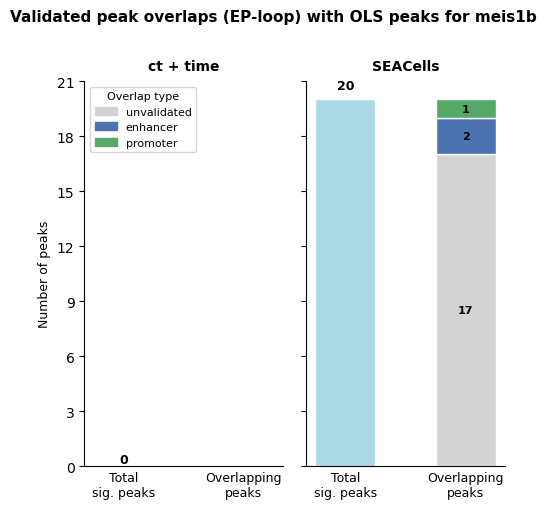

In [201]:
#stacked bar plot of the results of the correlation analysis for meis1b with the validation data peaks for meis1b

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── palette ──────────────────────────────────────────────────────────────────
overlap_colors = {
    "enhancer":    "#4C72B0",
    "promoter":  "#55A868",
    "unvalidated":     "lightgrey",
}
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

def get_color(overlap_type, idx):
    return overlap_colors.get(overlap_type, default_colors[idx % len(default_colors)])

def annotate_bar(ax, x, y_bottom, height, total, fontsize=8):
    """Annotate a bar segment: count + percentage of total."""
    if height == 0:
        return
    label = f"{int(height)}"
    ax.text(x, y_bottom + height / 2, label,
            ha="center", va="center", fontsize=fontsize,
            color="black", fontweight="bold")

# ── plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(5, 5), sharey=True)
titles    = ["ct + time", "SEACells"]
summaries = [ols_meis1b_ctt_summary, ols_meis1b_sc_summary]
# ── fixed stack order ─────────────────────────────────────────────────────────
stack_order = ["unvalidated", "enhancer", "promoter"]
x_total    = 0
x_overlap  = 0.7          # decrease this to close the gap (try 0.5–0.8)
bar_width  = 0.1
for ax, summary, title in zip(axes, summaries, titles):
    total = summary["total_count"].iloc[0]

    # reindex to enforce stack order (bottom → top)
    summary_ordered = (
        summary.set_index("overlap_type")
               .reindex(stack_order)
               .reset_index()
    )

    # — light blue bar: total significant peaks —
    ax.bar("Total\nsig. peaks", total, color="lightblue", edgecolor="white", width=0.5)
    ax.text("Total\nsig. peaks", total + total * 0.02, str(int(total)),
            ha="center", va="bottom", fontsize=9, fontweight="bold")

    # — stacked bar: overlap types in fixed order —
    bottom = 0
    for _, row in summary_ordered.iterrows():
        count = row["count"] if not pd.isna(row["count"]) else 0
        color = overlap_colors.get(row["overlap_type"], "grey")
        ax.bar("Overlapping\npeaks", count,
               bottom=bottom, label=row["overlap_type"],
               color=color, edgecolor="white", width=0.5)
        annotate_bar(ax, "Overlapping\npeaks", bottom, count, total)
        bottom += count

    # — axes formatting —
    ax.set_title(title, fontsize=10, fontweight="bold", pad=8)
    ax.set_ylabel("Number of peaks" if ax is axes[0] else "", fontsize=9)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", length=0, labelsize=9)

    # deduplicated legend in stack order — first panel only
    if ax is axes[0]:
        handles = [plt.Rectangle((0,0),1,1, color=overlap_colors[t]) for t in stack_order]
        ax.legend(handles, stack_order, title="Overlap type",
                  fontsize=8, title_fontsize=8, frameon=True, loc="upper right", bbox_to_anchor=(0.59, 1))
    else:
        ax.legend_.remove() if ax.legend_ else None

fig.suptitle("Validated peak overlaps (EP-loop) with OLS peaks for meis1b", fontsize=11, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# CRISPRi-mediated repression of distal enhancer in globin locus for genes (βe1, αe1, and αe3 )

1. Loaded the sgRNA seq from Supplementary Data of the paper
2. mapped the seq of all pos. sgRNAs to the zebrafish genome by BIO.. to get the peak location
3. mapped the seq of the ctrl sgRNA to the zebrafish the same way but all over the genome 
4. check for the globin genes in the 100kb window assignment, check the length of the peaks to see how to set up the overlapping conditions
5. check whether the sgRNAs are withing 100kb of the globin genes (they are!)

6. set the LCR boundary and the boundarz outside LCR
7. Load the results of OLS & COR, search for the three globin genes and compute how many of sgRNAs are overlapping with the selected peaks.

8. Overlap of sgRNAs in POSITIVE sig. peaks in all results --> looks ugh?

9. Check whether the overlapping peaks are assigned as significant in each df

### STEP 1 & 2

In [135]:
import re
import gzip
import pandas as pd
from Bio import SeqIO

# Dictionary of sgRNA sequences
sgRNA_dict = {
    "sgTS1": "GATCACTAATACGACTCACTATAGGATGCACAATCTGTCCCGGGTTTTAGAGCTAGAAATAGC",
    "sgTS2": "GATCACTAATACGACTCACTATAGGTCAGCTGTTTGTCTGTGAGTTTTAGAGCTAGAAATAGC",
    "sgTS3": "GATCACTAATACGACTCACTATAGGGTCCGTTTTAGAAGCCTGGTTTTAGAGCTAGAAATAGC",
    "sgTS4": "GATCACTAATACGACTCACTATAAGCAGCTGACTTTTTTCCAGGTTTTAGAGCTAGAAATAGC",
    "sgTS5": "GATCACTAATACGACTCACTATAGCTTGCTGTAACCTACCGAAGTTTTAGAGCTAGAAATAGC",
    "sgTS6": "GATCACTAATACGACTCACTATATCGCCTCATCAAGACCTGCTGTTTTAGAGCTAGAAATAGC",
    "sgCtrl": "GATCACTAATACGACTCACTATACCCCAGAAGTCCTCCAGTCCGTTTTAGAGCTAGAAATAGC",
}

# Reverse complement translation table
rc_map = str.maketrans("ACGTacgt", "TGCAtgca")

# Load genome once
fasta_file = "/home/fgsasse_lrs_1/Downloads/BA/data/Danio_rerio.GRCz11.dna.chromosome.3.fa.gz" #https://ftp.ensembl.org/pub/release-116/fasta/danio_rerio/dna/

with gzip.open(fasta_file, "rt") as handle:
    record = next(SeqIO.parse(handle, "fasta"))
    seq_str = str(record.seq).upper()

print(f"Loaded {record.id} ({len(seq_str):,} bp)")

# Store all hits
results = []

# Iterate over all sgRNAs
for sgRNA_name, full_seq in sgRNA_dict.items():

    # Extract the 20-nt protospacer
    target_seq = full_seq[25:43] 
    target_rc = target_seq.translate(rc_map)[::-1]

    print(f"\nSearching {sgRNA_name}")
    print(f"  + strand: {target_seq}")
    print(f"  - strand: {target_rc}")

    # Search forward and reverse strands
    for strand, query in [("+", target_seq), ("-", target_rc)]:
        for match in re.finditer(query, seq_str):

            start = match.start() + 1      # 1-based coordinates
            end = start + len(query) - 1

            print(f"  Hit: {strand} {start}-{end}")

            results.append({
                "sgRNA": sgRNA_name,
                "strand": strand,
                "start": start,
                "end": end
            })

# Convert to DataFrame
df_results = pd.DataFrame(results)

print(df_results)


Loaded 3 (62,628,489 bp)

Searching sgTS1
  + strand: ATGCACAATCTGTCCCGG
  - strand: CCGGGACAGATTGTGCAT
  Hit: - 55063489-55063506

Searching sgTS2
  + strand: TCAGCTGTTTGTCTGTGA
  - strand: TCACAGACAAACAGCTGA
  Hit: - 55066076-55066093

Searching sgTS3
  + strand: GTCCGTTTTAGAAGCCTG
  - strand: CAGGCTTCTAAAACGGAC
  Hit: + 55068542-55068559

Searching sgTS4
  + strand: CAGCTGACTTTTTTCCAG
  - strand: CTGGAAAAAAGTCAGCTG
  Hit: - 55069310-55069327

Searching sgTS5
  + strand: TTGCTGTAACCTACCGAA
  - strand: TTCGGTAGGTTACAGCAA
  Hit: + 55060067-55060084

Searching sgTS6
  + strand: GCCTCATCAAGACCTGCT
  - strand: AGCAGGTCTTGATGAGGC
  Hit: - 55057348-55057365

Searching sgCtrl
  + strand: CCAGAAGTCCTCCAGTCC
  - strand: GGACTGGAGGACTTCTGG
   sgRNA strand     start       end
0  sgTS1      -  55063489  55063506
1  sgTS2      -  55066076  55066093
2  sgTS3      +  55068542  55068559
3  sgTS4      -  55069310  55069327
4  sgTS5      +  55060067  55060084
5  sgTS6      -  55057348  55057365


In [136]:
#calculate the length of the sgRNA target sequences and add it as a new column in the dataframe
df_results["length"] = df_results["end"] - df_results["start"] 
df_results

,sgRNA,strand,start,end,length
0,sgTS1,-,55063489,55063506,17
1,sgTS2,-,55066076,55066093,17
2,sgTS3,+,55068542,55068559,17
3,sgTS4,-,55069310,55069327,17
4,sgTS5,+,55060067,55060084,17
5,sgTS6,-,55057348,55057365,17


55063488	55063506

In [3]:
#save the results to a CSV file
df_results.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Validation/sgRNAs_positions.csv", index=False)

### STEP 3

In [4]:
# Dictionary of sgRNA sequences
neg_sgRNA_dict = {
    "sgCtrl": "GATCACTAATACGACTCACTATACCCCAGAAGTCCTCCAGTCCGTTTTAGAGCTAGAAATAGC",
}

# Reverse complement translation table
rc_map = str.maketrans("ACGTacgt", "TGCAtgca")

# Load genome once
fasta_file = "/home/fgsasse_lrs_1/Downloads/BA/data/Danio_rerio.GRCz11.dna.primary_assembly.fa.gz" #https://ftp.ensembl.org/pub/release-116/fasta/danio_rerio/dna/

with gzip.open(fasta_file, "rt") as handle:
    record = next(SeqIO.parse(handle, "fasta"))
    seq_str = str(record.seq).upper()

print(f"Loaded {record.id} ({len(seq_str):,} bp)")

# Store all hits
results = []

# Iterate over all sgRNAs
for sgRNA_name, full_seq in neg_sgRNA_dict.items():

    # Extract the 20-nt protospacer
    target_seq = full_seq[25:43] 
    target_rc = target_seq.translate(rc_map)[::-1]

    print(f"\nSearching {sgRNA_name}")
    print(f"  + strand: {target_seq}")
    print(f"  - strand: {target_rc}")

    # Search forward and reverse strands
    for strand, query in [("+", target_seq), ("-", target_rc)]:
        for match in re.finditer(query, seq_str):

            start = match.start() + 1      # 1-based coordinates
            end = start + len(query) - 1

            print(f"  Hit: {strand} {start}-{end}")

            results.append({
                "sgRNA": sgRNA_name,
                "strand": strand,
                "start": start,
                "end": end
            })

# Convert to DataFrame
df_results = pd.DataFrame(results)

print(df_results)

Loaded 1 (59,578,282 bp)

Searching sgCtrl
  + strand: CCAGAAGTCCTCCAGTCC
  - strand: GGACTGGAGGACTTCTGG
Empty DataFrame
Columns: []
Index: []


### STEP 4

In [7]:
# Read the GTF file (from https://ftp.ensembl.org/pub/release-116/gtf/danio_rerio/)
gtf = pd.read_csv("/home/fgsasse_lrs_1/Downloads/Danio_rerio.GRCz11.116.chr.gtf.gz",
    sep="\t",
    comment="#",
    header=None,
    names=[
        "seqname", "source", "feature", "start", "end",
        "score", "strand", "frame", "attribute"
    ],
    compression="gzip"
)

print(gtf.head())

#find the gene_id for the gene_name 
genes = gtf[gtf["feature"] == "gene"].copy()

genes["gene_id"] = genes["attribute"].str.extract(r'gene_id "([^"]+)"')
genes["gene_name"] = genes["attribute"].str.extract(r'gene_name "([^"]+)"')

gene_name = genes.loc[
    genes["gene_name"] == "shha"
    "",
    "gene_id"
]

#gene_ID of the globin genes, the gene names were verified in https://zfin.org
print(genes.loc[genes["gene_name"] == "hbbe1.1", "gene_id"].iloc[0])
print(genes.loc[genes["gene_name"] == "hbae1.1", "gene_id"].iloc[0])
print(genes.loc[genes["gene_name"] == "hbae3", "gene_id"].iloc[0])

/tmp/ipykernel_1027163/3660878304.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  gtf = pd.read_csv("/home/fgsasse_lrs_1/Downloads/Danio_rerio.GRCz11.116.chr.gtf.gz",


  seqname  source  ... frame                                          attribute
0       4  havana  ...     .  gene_id "ENSDARG00000103202"; gene_version "2"...
1       4  havana  ...     .  gene_id "ENSDARG00000103202"; gene_version "2"...
2       4  havana  ...     .  gene_id "ENSDARG00000103202"; gene_version "2"...
3       4  havana  ...     .  gene_id "ENSDARG00000103202"; gene_version "2"...
4       4  havana  ...     .  gene_id "ENSDARG00000103202"; gene_version "2"...

[5 rows x 9 columns]
ENSDARG00000113599
ENSDARG00000089475
ENSDARG00000079305


In [5]:
#load /home/fgsasse_lrs_1/Downloads/BA/BA_data/TSS windows/20 windows/combined_gene_peak_assignments_100kb.csv
import pandas as pd

window_100kb_assignments = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/TSS windows/20 windows/combined_gene_peak_assignments_100kb.csv")
window_100kb_assignments.head()

,gene_id,assigned_peaks
0,a1cf,"['12-6186644-6187111', '12-6190483-6191143', '..."
1,a2ml,"['15-21143884-21144162', '15-21033797-21034001..."
2,aaas,"['9-323370-323691', '9-209853-211311', '9-2304..."
3,aacs,"['5-18949828-18950713', '5-18811696-18812645',..."
4,aadac,"['15-1052335-1053001', '15-1029184-1030074', '..."


In [6]:
#vector for the gene names of the globin genes (βe1, αe1, and αe3 were selected as target genes)
globin_gene_names = ["hbbe1.1", "hbae1.1", "hbae3"]

#search for the gene_ids of the globin genes in the gtf dataframe

globin_gene_ids = window_100kb_assignments[
    window_100kb_assignments["gene_id"].isin(globin_gene_names)
].copy()


#calculate the mean length of the peaks for the globin genes in the window_100kb_assignments dataframe
import re

def clean_int(x):
    return int(re.sub(r"[^\d]", "", x))  # removes anything not a digit

def peak_lengths(peaks):
    lengths = []

    for p in peaks.split(","):
        parts = p.split("-")

        if len(parts) == 3:
            start = clean_int(parts[1])
            end = clean_int(parts[2])
            lengths.append(end - start)

    return lengths

globin_peak_lengths = globin_gene_ids["assigned_peaks"].apply(peak_lengths)

mean_per_gene = globin_peak_lengths.apply(
    lambda x: sum(x) / len(x) if len(x) > 0 else 0
)

overall_mean = mean_per_gene.mean()

print(f"Mean peak length per gene (averaged across genes): {overall_mean:.2f} bp")
print("Mean peak length per gene:")
for gene, mean_length in zip(globin_gene_ids["gene_id"], mean_per_gene):
    print(f"{gene}: {mean_length:.2f} bp")

Mean peak length per gene (averaged across genes): 702.30 bp
Mean peak length per gene:
hbae1.1: 706.64 bp
hbae3: 716.82 bp
hbbe1.1: 683.42 bp


### STEP 5

In [3]:
#check the distance of the sgRNA peaks to the TSS of the globin genes in the window_100kb_assignments dataframe
import pandas as pd

sgRNA_pos = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Validation/sgRNAs_positions.csv")

In [8]:
#filter genes by the globin gene names
globin_genes = gtf[gtf["feature"] == "gene"].copy()
globin_genes["gene_id"] = globin_genes["attribute"].str.extract(r'gene_id "([^"]+)"')
globin_genes["gene_name"] = globin_genes["attribute"].str.extract(r'gene_name "([^"]+)"')
globin_genes = globin_genes[globin_genes["gene_name"].isin(globin_gene_names)]
print(globin_genes.head())

#calculate the distance of the sgRNA peaks to the TSS of the globin genes in the window_100kb_assignments dataframe
def calculate_distance_to_tss(sgRNA_row, gene_row):
    sgRNA_start = sgRNA_row["start"]
    sgRNA_end = sgRNA_row["end"]
    gene_start = gene_row["start"]
    gene_end = gene_row["end"]
    gene_strand = gene_row["strand"]

    # Determine TSS based on strand
    if gene_strand == "+":
        tss = gene_start
    else:
        tss = gene_end

    # Calculate distance to TSS
    if sgRNA_end < tss:
        return tss - sgRNA_end  # sgRNA is upstream of TSS
    else:
        return 0  # sgRNA overlaps TSS

calculate_distances = []
for _, sgRNA_row in sgRNA_pos.iterrows():
    for _, gene_row in globin_genes.iterrows():
        distance = calculate_distance_to_tss(sgRNA_row, gene_row)
        calculate_distances.append({
            "sgRNA": sgRNA_row["sgRNA"],
            "gene_name": gene_row["gene_name"],
            "distance_to_TSS": distance
        })

calculate_distances_df = pd.DataFrame(calculate_distances)
print(calculate_distances_df)

       seqname          source  ...             gene_id  gene_name
223950       3  ensembl_havana  ...  ENSDARG00000113599    hbbe1.1
223965       3  ensembl_havana  ...  ENSDARG00000089475    hbae1.1
224090       3  ensembl_havana  ...  ENSDARG00000079305      hbae3

[3 rows x 11 columns]
    sgRNA gene_name  distance_to_TSS
0   sgTS1   hbbe1.1            50591
1   sgTS1   hbae1.1            57619
2   sgTS1     hbae3            84282
3   sgTS2   hbbe1.1            48004
4   sgTS2   hbae1.1            55032
5   sgTS2     hbae3            81695
6   sgTS3   hbbe1.1            45538
7   sgTS3   hbae1.1            52566
8   sgTS3     hbae3            79229
9   sgTS4   hbbe1.1            44770
10  sgTS4   hbae1.1            51798
11  sgTS4     hbae3            78461
12  sgTS5   hbbe1.1            54013
13  sgTS5   hbae1.1            61041
14  sgTS5     hbae3            87704
15  sgTS6   hbbe1.1            56732
16  sgTS6   hbae1.1            63760
17  sgTS6     hbae3            90423


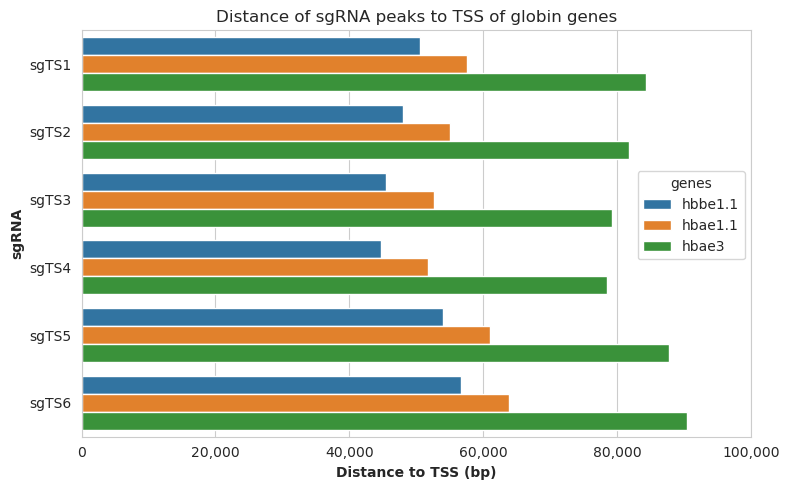

In [32]:
#plot the distances of the sgRNA peaks to the TSS of the globin genes in a bar plot
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=calculate_distances_df,
    x="distance_to_TSS",
    y="sgRNA",
    hue="gene_name",
    ax=ax
)
sns.set_style("whitegrid", {"axis.facecolor": "lightgray"})
ax.set_title("Distance of sgRNA peaks to TSS of globin genes")
ax.set_xlabel("Distance to TSS (bp)", fontweight='bold')
ax.set_ylabel("sgRNA", fontweight='bold')
ax.set_xlim(0,100000)
#lable the x-axis ticks aligned to x axis and not rotated
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='x', rotation=0)
ax.legend(title="genes", bbox_to_anchor=(0.82, 0.67), loc='upper left')
plt.tight_layout()
plt.savefig("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Validation/sgRNA_distance_to_TSS_globin_genes.png", dpi=300)
plt.show()  

In [157]:
#check if all peaks are within 100kb of the TSS of the globin genes
print("peaks above 100kb of TSS:", (calculate_distances_df["distance_to_TSS"] >= 100000).sum())

peaks above 100kb of TSS: 0


### STEP 6

In [202]:
#set the boudaries of the LCR region based on the sgRNA positions for sgTS1 and sgTS4, bases on sgTS5 and sgTS6, the LCR region is defined as the region between sgTS1 and sgTS4, which are the most upstream and downstream sgRNAs, respectively. The LCR region is defined as the region between the start of sgTS1 and the end of sgTS4.

# Get the LCR boundaries
lcr_start = sgRNA_pos.loc[sgRNA_pos["sgRNA"] == "sgTS1", "start"].iloc[0]
lcr_end = sgRNA_pos.loc[sgRNA_pos["sgRNA"] == "sgTS4", "end"].iloc[0]

lcr_peak = "3" + "-" + str(lcr_start) + "-" + str(lcr_end) 

print(lcr_peak)

#the non LCR boundaries
non_lcr_start = sgRNA_pos.loc[sgRNA_pos["sgRNA"] == "sgTS6", "start"].iloc[0]
non_lcr_end = sgRNA_pos.loc[sgRNA_pos["sgRNA"] == "sgTS5", "end"].iloc[0]

non_lcr_peak = "3" + "-" + str(non_lcr_start) + "-" + str(non_lcr_end)
print(non_lcr_peak)

3-55063489-55069327
3-55057348-55060084


### STEP 7

In [10]:
import pandas as pd

#Correlation results
cor_res_100kb_ctt = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Results/gene_peak_correlation_ct_time_100kb_results.csv")
print(cor_res_100kb_ctt.head())
cor_100kb_df_sc = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Results/gene_peak_correlation_sc_100kb_results.csv")
print(cor_100kb_df_sc.head())


#OLS results
ols_res_df_ctt = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_res_all_windows_range_df_ct_time.csv")
ols_res_100kb_ctt = ols_res_df_ctt[ols_res_df_ctt["window"] == "100kb"].copy()
ols_res_100kb_ctt.head()


ols_res_df_sc = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_results_100kb_df_sc.csv")
ols_res_100kb_sc = ols_res_df_sc[ols_res_df_sc["window"] == "100kb"].copy()
ols_res_100kb_sc.head()


  window  gene                peak  correlation    pvalue  neglog10_pvalue  \
0  100kb  a1cf  12-6186644-6187111     0.193512  0.006576         2.182015   
1  100kb  a1cf  12-6190483-6191143     0.135734  0.057840         1.237772   
2  100kb  a1cf  12-6225169-6226018     0.080739  0.260606         0.584015   
3  100kb  a1cf  12-6114452-6114950     0.125358  0.079997         1.096924   
4  100kb  a1cf  12-6140521-6140735     0.040975  0.568525         0.245251   

       padj  neglog10_padj  
0  0.034600       1.460927  
1  0.173677       0.760259  
2  0.472269       0.325810  
3  0.217494       0.662553  
4  0.748452       0.125836  
  window  gene                peak  correlation    pvalue  neglog10_pvalue  \
0  100kb  a1cf  12-6186644-6187111     0.121149  0.000016         4.791006   
1  100kb  a1cf  12-6190483-6191143     0.117048  0.000031         4.506702   
2  100kb  a1cf  12-6225169-6226018     0.061143  0.029989         1.523041   
3  100kb  a1cf  12-6114452-6114950     0.0603

,window,gene,peak,coef,pval,category
0,100kb,a1cf,12-6186644-6187111,0.021198,0.056007,non-significant
1,100kb,a1cf,12-6190483-6191143,0.018545,0.063436,non-significant
2,100kb,a1cf,12-6225169-6226018,-0.005018,0.621363,non-significant
3,100kb,a1cf,12-6114452-6114950,-0.001729,0.865097,non-significant
4,100kb,a1cf,12-6140521-6140735,-0.013947,0.155559,non-significant


In [11]:
# classify every peak–gene pair into one of three categories
def classify_pair(row):
    if row["padj"] <= 0.05 and row["correlation"] < 0:
        return "sig. negative"
    elif row["padj"] <= 0.05 and row["correlation"] > 0:
        return "sig. positive"
    else:
        return "non-significant"

cor_res_100kb_ctt["category"] = cor_res_100kb_ctt.apply(classify_pair, axis=1)
cor_100kb_df_sc["category"] = cor_100kb_df_sc.apply(classify_pair, axis=1)    

In [12]:
#filter all four result by the three globin genes (hbbe1.1, hbae1.1, hbae3) 
globin_genes = ["hbbe1.1", "hbae1.1", "hbae3"]

cor_globin_ctt= cor_res_100kb_ctt[
    (cor_res_100kb_ctt["gene"].isin(globin_genes))].copy()

cor_globin_sc= cor_100kb_df_sc[
    (cor_100kb_df_sc["gene"].isin(globin_genes))].copy()

ols_globin_ctt= ols_res_100kb_ctt[
    (ols_res_100kb_ctt["gene"].isin(globin_genes))].copy()

ols_globin_sc= ols_res_100kb_sc[
    (ols_res_100kb_sc["gene"].isin(globin_genes))].copy()


In [13]:
#make a list of significant peaks for the three globin genes in the correlation results and filter for significant peaks
cor_globin_sig_ctt = cor_globin_ctt[(cor_globin_ctt["category"].isin(["sig. negative", "sig. positive"]))]
cor_globin_sig_sc = cor_globin_sc[(cor_globin_sc["category"].isin(["sig. negative", "sig. positive"]))]

print(cor_globin_sig_ctt.groupby("gene").size().reset_index(name="count"))
print(cor_globin_sig_sc.groupby("gene").size().reset_index(name="count"))

#make a list of significant peaks for the three globin genes in the OLS results and filter for significant peaks
ols_globin_sig_ctt = ols_globin_ctt[(ols_globin_ctt["category"].isin(["sig. negative", "sig. positive"]))]
ols_globin_sig_sc = ols_globin_sc[(ols_globin_sc["category"].isin(["sig. negative", "sig. positive"]))]

print(ols_globin_sig_ctt.groupby("gene").size().reset_index(name="count"))
print(ols_globin_sig_sc.groupby("gene").size().reset_index(name="count"))

      gene  count
0  hbae1.1     48
1    hbae3     53
2  hbbe1.1     49
      gene  count
0  hbae1.1     45
1    hbae3     41
2  hbbe1.1     46
      gene  count
0  hbae1.1      9
1    hbae3     13
2  hbbe1.1      9
      gene  count
0  hbae1.1     24
1    hbae3     27
2  hbbe1.1     29


In [14]:
#filter all list of sig. peaks only for positive peaks for the three globin genes in the correlation results
cor_globin_sig_pos_ctt = cor_globin_sig_ctt[(cor_globin_sig_ctt["category"] == "sig. positive")]
cor_globin_sig_pos_sc = cor_globin_sig_sc[(cor_globin_sig_sc["category"] == "sig. positive")]

ols_globin_sig_pos_ctt = ols_globin_sig_ctt[(ols_globin_sig_ctt["category"] == "sig. positive")]
ols_globin_sig_pos_sc = ols_globin_sig_sc[(ols_globin_sig_sc["category"] == "sig. positive")]

print(cor_globin_sig_pos_ctt.groupby("gene").size().reset_index(name="count"))
print(cor_globin_sig_pos_sc.groupby("gene").size().reset_index(name="count"))
print(ols_globin_sig_pos_ctt.groupby("gene").size().reset_index(name="count"))
print(ols_globin_sig_pos_sc.groupby("gene").size().reset_index(name="count"))

      gene  count
0  hbbe1.1      5
      gene  count
0  hbae1.1     27
1    hbae3     26
2  hbbe1.1      8
      gene  count
0  hbae1.1      6
1    hbae3      8
2  hbbe1.1      6
      gene  count
0  hbae1.1     12
1    hbae3     14
2  hbbe1.1     13


In [16]:
#calculate the mean length of the peaks for the globin genes in all results (correlation and OLS) and print the mean length per gene and the overall mean length across genes
import re

def clean_int(x):
    return int(re.sub(r"[^\d]", "", x))  # removes anything not a digit

def peak_lengths(peaks):
    lengths = []

    for p in peaks.split(","):
        parts = p.split("-")

        if len(parts) == 3:
            start = clean_int(parts[1])
            end = clean_int(parts[2])
            lengths.append(end - start)

    return lengths

cor_sig_pos_ctt = cor_globin_sig_pos_ctt["peak"].apply(peak_lengths)

mean_per_gene = cor_sig_pos_ctt.apply(
    lambda x: sum(x) / len(x) if len(x) > 0 else 0
)

overall_mean = mean_per_gene.mean()

print(f"Mean peak length per gene (averaged across genes, cor_sig_pos_ctt): {overall_mean:.2f} bp")
print("Mean peak length per gene:")
for gene, mean_length in zip(cor_globin_sig_pos_ctt.groupby("gene").groups.keys(), mean_per_gene):
    print(f"{gene}: {mean_length:.2f} bp")

cor_sig_pos_sc = cor_globin_sig_pos_sc["peak"].apply(peak_lengths)  

mean_per_gene = cor_sig_pos_sc.apply(
    lambda x: sum(x) / len(x) if len(x) > 0 else 0
)

overall_mean = mean_per_gene.mean()

print(f"Mean peak length per gene (averaged across genes, cor_sig_pos_sc): {overall_mean:.2f} bp")
print("Mean peak length per gene:")
for gene, mean_length in zip(cor_globin_sig_pos_sc.groupby("gene").groups.keys(), mean_per_gene):
    print(f"{gene}: {mean_length:.2f} bp")


ols_sig_pos_ctt = ols_globin_sig_pos_ctt["peak"].apply(peak_lengths)

mean_per_gene = ols_sig_pos_ctt.apply(
    lambda x: sum(x) / len(x) if len(x) > 0 else 0
)

overall_mean = mean_per_gene.mean()

print(f"Mean peak length per gene (averaged across genes, ols_sig_pos_ctt): {overall_mean:.2f} bp")
print("Mean peak length per gene:")
for gene, mean_length in zip(ols_globin_sig_pos_ctt.groupby("gene").groups.keys(), mean_per_gene):
    print(f"{gene}: {mean_length:.2f} bp")


ols_sig_pos_sc = ols_globin_sig_pos_sc["peak"].apply(peak_lengths)  
mean_per_gene = ols_sig_pos_sc.apply(
    lambda x: sum(x) / len(x) if len(x) > 0 else 0
)

overall_mean = mean_per_gene.mean()

print(f"Mean peak length per gene (averaged across genes, ols_sig_pos_sc): {overall_mean:.2f} bp")
print("Mean peak length per gene:")
for gene, mean_length in zip(ols_globin_sig_pos_sc.groupby("gene").groups.keys(), mean_per_gene):
    print(f"{gene}: {mean_length:.2f} bp")  
    

Mean peak length per gene (averaged across genes, cor_sig_pos_ctt): 583.80 bp
Mean peak length per gene:
hbbe1.1: 240.00 bp
Mean peak length per gene (averaged across genes, cor_sig_pos_sc): 682.89 bp
Mean peak length per gene:
hbae1.1: 565.00 bp
hbae3: 497.00 bp
hbbe1.1: 642.00 bp
Mean peak length per gene (averaged across genes, ols_sig_pos_ctt): 563.25 bp
Mean peak length per gene:
hbae1.1: 341.00 bp
hbae3: 515.00 bp
hbbe1.1: 487.00 bp
Mean peak length per gene (averaged across genes, ols_sig_pos_sc): 604.05 bp
Mean peak length per gene:
hbae1.1: 497.00 bp
hbae3: 731.00 bp
hbbe1.1: 621.00 bp


In [17]:
#make a dataframe with the columns, chromosome, start, end, gene of cor_globin_sig_pos_ctt, cor_globin_sig_pos_sc, ols_globin_sig_pos_ctt, ols_globin_sig_pos_sc
dfs = {
    "long_cor_ctt_df": cor_globin_sig_pos_ctt,
    "long_cor_sc_df": cor_globin_sig_pos_sc,
    "long_ols_ctt_df": ols_globin_sig_pos_ctt,
    "long_ols_sc_df": ols_globin_sig_pos_sc,
}

long_dfs = {}

for name, df in dfs.items():
    peak_split = df["peak"].str.split("-", expand=True)

    long_dfs[name] = pd.DataFrame({
        "chr": peak_split[0].str.replace("chr", "").astype(int),
        "start": peak_split[1].astype(int),
        "end": peak_split[2].astype(int),
        "gene": df["gene"]
    })

In [18]:
#how many peaks are in each of the four dataframes
for name, df in dfs.items():
    print(f"{name}: {len(df)} peaks")
    

long_cor_ctt_df: 5 peaks
long_cor_sc_df: 61 peaks
long_ols_ctt_df: 20 peaks
long_ols_sc_df: 39 peaks


In [19]:
long_dfs["long_cor_sc_df"]

,chr,start,end,gene
606225,3,55120668,55121233,hbae1.1
606232,3,55127390,55127887,hbae1.1
606236,3,55074380,55075022,hbae1.1
606239,3,55131220,55132001,hbae1.1
606242,3,55059606,55060212,hbae1.1
...,...,...,...,...
606890,3,55145073,55145804,hbbe1.1
606912,3,55078656,55080107,hbbe1.1
606920,3,55081731,55081955,hbbe1.1
606945,3,55127936,55128430,hbbe1.1


Now creating bedfiles to compute how many sgRNAs are retained in pos. selected peaks

In [20]:
#bed files of the sgRNAs and the LCR region for the globin genes
sgRNA_bed = pd.DataFrame({
    "chr": ["3"] * len(sgRNA_pos),
    "start": sgRNA_pos["start"] - 1,
    "end": sgRNA_pos["end"],
    "name": sgRNA_pos["sgRNA"]
})

sgRNA_bed.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Validation/bedfiles/sgRNAs.bed", sep="\t", header=False, index=False)

#bed files for the significant peaks for the three globin genes in the correlation and OLS results
for name, df in long_dfs.items():
    bed_df = pd.DataFrame({
        "chr": df["chr"],
        "start": df["start"] - 1,   # GTF 1-based → BED 0-based
        "end": df["end"],
        "name": df["gene"]
    })
    bed_df.to_csv(f"/home/fgsasse_lrs_1/Downloads/BA/BA_data/Validation/bedfiles/{name.replace('_df','')}.bed", sep="\t", header=False, index=False)


In [21]:
# after bedtools intersect -a short_peaks.bed -b long_peaks.bed -wa -wb > .txt
import pandas as pd
cor_ctt_overlap = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Validation/overlap results/sgRNA_overlap_cor_ctt.txt", sep="\t", header=None,
                              names=["sgRNA_chr", "sgRNA_start", "sgRNA_end", "sgRNA", "gene_chr", "peak_start", "peak_end", "gene"])

cor_sc_overlap = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Validation/overlap results/sgRNA_overlap_cor_sc.txt", sep="\t", header=None,
                              names=["sgRNA_chr", "sgRNA_start", "sgRNA_end", "sgRNA", "gene_chr", "peak_start", "peak_end", "gene"])

ols_ctt_overlap = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Validation/overlap results/sgRNA_overlap_ols_ctt.txt", sep="\t", header=None,
                              names=["sgRNA_chr", "sgRNA_start", "sgRNA_end", "sgRNA", "gene_chr", "peak_start", "peak_end", "gene"])
ols_sc_overlap = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Validation/overlap results/sgRNA_overlap_ols_sc.txt", sep="\t", header=None,
                              names=["sgRNA_chr", "sgRNA_start", "sgRNA_end", "sgRNA", "gene_chr", "peak_start", "peak_end", "gene"])


In [49]:
cor_sc_overlap

,sgRNA_chr,sgRNA_start,sgRNA_end,sgRNA,gene_chr,peak_start,peak_end,gene
0,3,55066075,55066093,sgTS2,3,55065588,55066152,hbae1.1
1,3,55066075,55066093,sgTS2,3,55065588,55066152,hbae3
2,3,55069309,55069327,sgTS4,3,55068816,55069400,hbae1.1
3,3,55069309,55069327,sgTS4,3,55068816,55069400,hbae3
4,3,55060066,55060084,sgTS5,3,55059605,55060212,hbae1.1
5,3,55060066,55060084,sgTS5,3,55059605,55060212,hbae3


In [22]:
print(cor_ctt_overlap.groupby(["sgRNA", "gene"]).size().reset_index(name="count"))
print(cor_sc_overlap.groupby(["sgRNA", "gene"]).size().reset_index(name="count"))
print(ols_ctt_overlap.groupby(["sgRNA", "gene"]).size().reset_index(name="count"))
print(ols_sc_overlap.groupby(["sgRNA", "gene"]).size().reset_index(name="count"))

Empty DataFrame
Columns: [sgRNA, gene, count]
Index: []
   sgRNA     gene  count
0  sgTS2  hbae1.1      1
1  sgTS2    hbae3      1
2  sgTS4  hbae1.1      1
3  sgTS4    hbae3      1
4  sgTS5  hbae1.1      1
5  sgTS5    hbae3      1
   sgRNA   gene  count
0  sgTS5  hbae3      1
Empty DataFrame
Columns: [sgRNA, gene, count]
Index: []


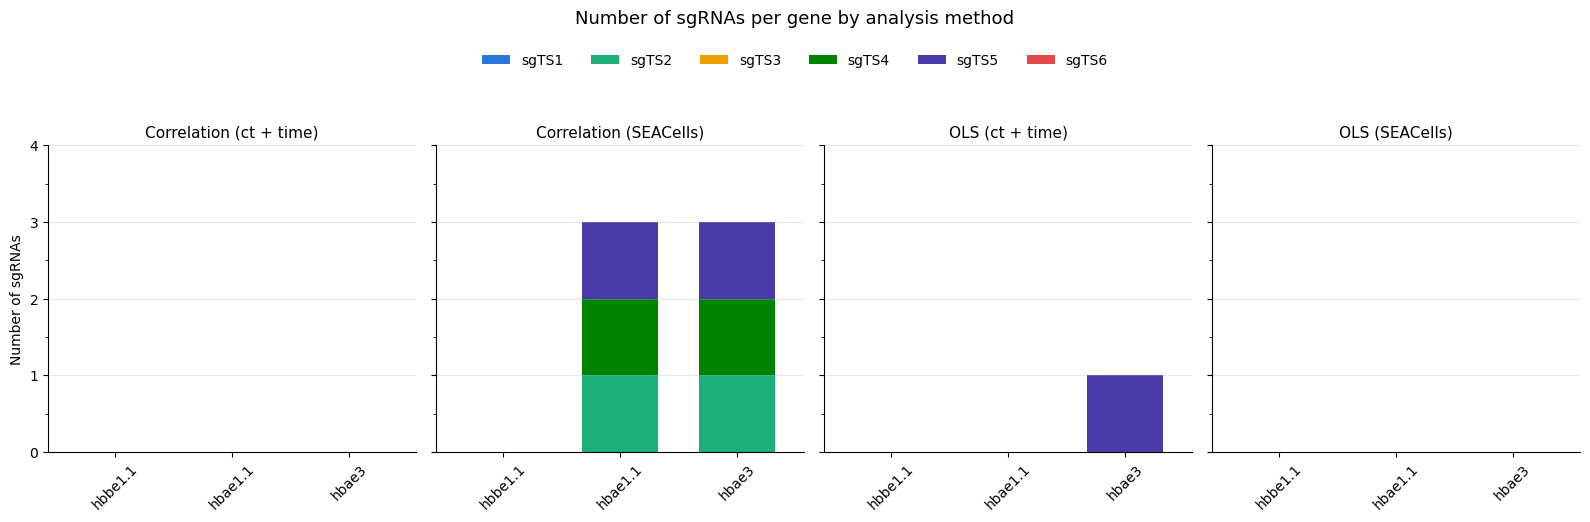

In [46]:
import matplotlib.pyplot as plt
import pandas as pd

dfs = {
    "Correlation (ct + time)": cor_ctt_overlap,
    "Correlation (SEACells)":  cor_sc_overlap,
    "OLS (ct + time)":         ols_ctt_overlap,
    "OLS (SEACells)":          ols_sc_overlap,
}

sg_order = ["sgTS1", "sgTS2", "sgTS3", "sgTS4", "sgTS5", "sgTS6"]
sg_colors = {
    "sgTS1": "#2a78d6", "sgTS2": "#1baf7a", "sgTS3": "#eda100",
    "sgTS4": "#008300", "sgTS5": "#4a3aa7", "sgTS6": "#e34948",
}

# Fixed gene order, set explicitly instead of derived from the data
all_genes = ["hbbe1.1","hbae1.1", "hbae3"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5), sharey=True)

for ax, (name, df) in zip(axes, dfs.items()):
    if df.empty:
        counts = pd.DataFrame(0, index=all_genes, columns=sg_order)
    else:
        counts = (
            df.groupby(["gene", "sgRNA"]).size()
            .unstack(fill_value=0)
            .reindex(index=all_genes, columns=sg_order, fill_value=0)
        )

    counts.plot(
        kind="bar", stacked=True, ax=ax,
        color=[sg_colors[c] for c in counts.columns],
        width=0.65, legend=False,
    )
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Number of sgRNAs" if ax is axes[0] else "")
    ax.set_ylim(0, 4)
    ax.set_yticks(range(0, 5, 1))
    ax.tick_params(axis="x", rotation=45)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle="-", alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=6, bbox_to_anchor=(0.5, 1.08), frameon=False)
fig.suptitle("Number of sgRNAs per gene by analysis method", y=1.15, fontsize=13)
plt.tight_layout()
plt.savefig("sgrna_overlap_by_method.png", dpi=300, bbox_inches="tight")
plt.show()

Trying the overlap with the sgRNAs with all peaks

In [24]:
#filter all four result by the three globin genes (hbbe1.1, hbae1.1, hbae3) 
globin_genes = ["hbbe1.1", "hbae1.1", "hbae3"]

cor_globin_ctt= cor_res_100kb_ctt[
    (cor_res_100kb_ctt["gene"].isin(globin_genes))].copy()

cor_globin_sc= cor_100kb_df_sc[
    (cor_100kb_df_sc["gene"].isin(globin_genes))].copy()

ols_globin_ctt= ols_res_100kb_ctt[
    (ols_res_100kb_ctt["gene"].isin(globin_genes))].copy()

ols_globin_sc= ols_res_100kb_sc[
    (ols_res_100kb_sc["gene"].isin(globin_genes))].copy()

#make a dataframe with the columns, chromosome, start, end, gene of cor_globin_sig_pos_ctt, cor_globin_sig_pos_sc, ols_globin_sig_pos_ctt, ols_globin_sig_pos_sc
dfs = {
    "cor_ctt_df": cor_globin_ctt,
    "cor_sc_df": cor_globin_sc,
    "ols_ctt_df": ols_globin_ctt,
    "ols_sc_df": ols_globin_sc,
}

all_peaks_dfs = {}

for name, df in dfs.items():
    peak_split = df["peak"].str.split("-", expand=True)

    all_peaks_dfs[name] = pd.DataFrame({
        "chr": peak_split[0].str.replace("chr", "").astype(int),
        "start": peak_split[1].astype(int),
        "end": peak_split[2].astype(int),
        "gene": df["gene"]
    })

In [25]:
#how many peaks are in each of the four dataframes
for name, df in all_peaks_dfs.items():
    print(f"{name}: {len(df)} peaks")
    

cor_ctt_df: 319 peaks
cor_sc_df: 319 peaks
ols_ctt_df: 319 peaks
ols_sc_df: 319 peaks


In [ ]:
#bed files of the sgRNAs and the peaks for the globin genes

#bed files with all peaks for the three globin genes in the correlation and OLS results
for name, df in all_peaks_dfs.items():
    bed_df = pd.DataFrame({
        "chr": df["chr"],
        "start": df["start"] - 1,   # GTF 1-based → BED 0-based
        "end": df["end"],
        "name": df["gene"]
    })
    bed_df.to_csv(f"/home/fgsasse_lrs_1/Downloads/BA/BA_data/Validation/bedfiles/{name.replace('_df','')}.bed", sep="\t", header=False, index=False)

In [1]:
# after bedtools intersect -a short_peaks.bed -b long_peaks.bed -wa -wb > .txt
import pandas as pd
cor_ctt = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/sgRNA_overlap_cor_ctt_all.txt", sep="\t", header=None,
                              names=["sgRNA_chr", "sgRNA_start", "sgRNA_end", "sgRNA", "gene_chr", "peak_start", "peak_end", "gene"])

cor_sc = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/sgRNA_overlap_cor_sc_all.txt", sep="\t", header=None,
                              names=["sgRNA_chr", "sgRNA_start", "sgRNA_end", "sgRNA", "gene_chr", "peak_start", "peak_end", "gene"])

ols_ctt = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/sgRNA_overlap_ols_ctt_all.txt", sep="\t", header=None,
                              names=["sgRNA_chr", "sgRNA_start", "sgRNA_end", "sgRNA", "gene_chr", "peak_start", "peak_end", "gene"])
ols_sc = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/sgRNA_overlap_ols_sc_all.txt", sep="\t", header=None,
                              names=["sgRNA_chr", "sgRNA_start", "sgRNA_end", "sgRNA", "gene_chr", "peak_start", "peak_end", "gene"])


In [2]:
#check for all peaks in the four dataframes if thee sgRNAs are within the peak region

if not cor_ctt.empty:
    cor_ctt["sgRNA_within_peak"] = (
        (cor_ctt["sgRNA_start"] >= cor_ctt["peak_start"]) &
        (cor_ctt["sgRNA_end"] <= cor_ctt["peak_end"])
    )

if not cor_sc.empty:
    cor_sc["sgRNA_within_peak"] = (
        (cor_sc["sgRNA_start"] >= cor_sc["peak_start"]) &
        (cor_sc["sgRNA_end"] <= cor_sc["peak_end"])
    )   

if not ols_ctt.empty:
    ols_ctt["sgRNA_within_peak"] = (
        (ols_ctt["sgRNA_start"] >= ols_ctt["peak_start"]) &
        (ols_ctt["sgRNA_end"] <= ols_ctt["peak_end"])
    )

if not ols_sc.empty:
    ols_sc["sgRNA_within_peak"] = (
        (ols_sc["sgRNA_start"] >= ols_sc["peak_start"]) &
        (ols_sc["sgRNA_end"] <= ols_sc["peak_end"])
    )

#see for any false in the sgRNA_within_peak column in the four dataframes
print("cor_ctt:", cor_ctt[~cor_ctt["sgRNA_within_peak"]]) 
print("cor_sc:", cor_sc[~cor_sc["sgRNA_within_peak"]])
print("ols_ctt:", ols_ctt[~ols_ctt["sgRNA_within_peak"]])
print("ols_sc:", ols_sc[~ols_sc["sgRNA_within_peak"]])

cor_ctt: Empty DataFrame
Columns: [sgRNA_chr, sgRNA_start, sgRNA_end, sgRNA, gene_chr, peak_start, peak_end, gene, sgRNA_within_peak]
Index: []
cor_sc: Empty DataFrame
Columns: [sgRNA_chr, sgRNA_start, sgRNA_end, sgRNA, gene_chr, peak_start, peak_end, gene, sgRNA_within_peak]
Index: []
ols_ctt: Empty DataFrame
Columns: [sgRNA_chr, sgRNA_start, sgRNA_end, sgRNA, gene_chr, peak_start, peak_end, gene, sgRNA_within_peak]
Index: []
ols_sc: Empty DataFrame
Columns: [sgRNA_chr, sgRNA_start, sgRNA_end, sgRNA, gene_chr, peak_start, peak_end, gene, sgRNA_within_peak]
Index: []


In [3]:
#count the unique peaks in the four dataframes
print("cor_ctt unique peaks:", cor_ctt[["gene_chr", "peak_start", "peak_end"]].drop_duplicates().shape[0])
print("cor_sc unique peaks:", cor_sc[["gene_chr", "peak_start", "peak_end"]].drop_duplicates().shape[0])
print("ols_ctt unique peaks:", ols_ctt[["gene_chr", "peak_start", "peak_end"]].drop_duplicates().shape[0])
print("ols_sc unique peaks:", ols_sc[["gene_chr", "peak_start", "peak_end"]].drop_duplicates().shape[0])

cor_ctt unique peaks: 5
cor_sc unique peaks: 5
ols_ctt unique peaks: 5
ols_sc unique peaks: 5


In [4]:
#get the unique peaks in the four dataframes and save them to a new dataframe with the columns, chromosome, start, end, gene
cor_ctt_unique_peaks = cor_ctt[["sgRNA", "gene_chr", "peak_start", "peak_end", "gene"]].drop_duplicates().copy()
cor_sc_unique_peaks = cor_sc[["sgRNA", "gene_chr", "peak_start", "peak_end", "gene"]].drop_duplicates().copy()
ols_ctt_unique_peaks = ols_ctt[["sgRNA", "gene_chr", "peak_start", "peak_end", "gene"]].drop_duplicates().copy()
ols_sc_unique_peaks = ols_sc[["sgRNA", "gene_chr", "peak_start", "peak_end", "gene"]].drop_duplicates().copy()

print(cor_ctt_unique_peaks.head())
print(cor_sc_unique_peaks.head())
print(ols_ctt_unique_peaks.head())
print(ols_sc_unique_peaks.head())

   sgRNA  gene_chr  peak_start  peak_end     gene
0  sgTS1         3    55063040  55063541  hbae1.1
1  sgTS1         3    55063040  55063541    hbae3
2  sgTS1         3    55063040  55063541  hbbe1.1
3  sgTS2         3    55065588  55066152  hbae1.1
4  sgTS2         3    55065588  55066152    hbae3
   sgRNA  gene_chr  peak_start  peak_end     gene
0  sgTS1         3    55063040  55063541  hbae1.1
1  sgTS1         3    55063040  55063541    hbae3
2  sgTS1         3    55063040  55063541  hbbe1.1
3  sgTS2         3    55065588  55066152  hbae1.1
4  sgTS2         3    55065588  55066152    hbae3
   sgRNA  gene_chr  peak_start  peak_end     gene
0  sgTS1         3    55063040  55063541  hbae1.1
1  sgTS1         3    55063040  55063541    hbae3
2  sgTS1         3    55063040  55063541  hbbe1.1
3  sgTS2         3    55065588  55066152  hbae1.1
4  sgTS2         3    55065588  55066152    hbae3
   sgRNA  gene_chr  peak_start  peak_end     gene
0  sgTS1         3    55063040  55063541  hbae1.1


In [5]:
#make a column "peak position" in the four dataframes with the format "chr3:start-end"
cor_ctt["peak_position"] = "chr3:" + cor_ctt["peak_start"].astype(str) + "-" + cor_ctt["peak_end"].astype(str)
cor_sc["peak_position"] = "chr3:" + cor_sc["peak_start"].astype(str) + "-" + cor_sc["peak_end"].astype(str)
ols_ctt["peak_position"] = "chr3:" + ols_ctt["peak_start"].astype(str) + "-" + ols_ctt["peak_end"].astype(str)
ols_sc["peak_position"] = "chr3:" + ols_sc["peak_start"].astype(str) + "-" + ols_sc["peak_end"].astype(str)

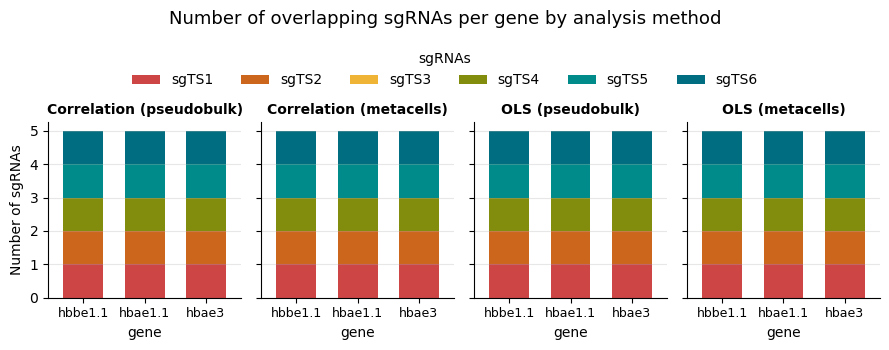

In [17]:
#plot the number of sgRNAs per gene for each of the four results (correlation and OLS) in a stacked bar plot, with the x-axis as the gene names and the y-axis as the number of sgRNAs, and the colors representing the different sgRNAs (sgTS1, sgTS2, sgTS3, sgTS4, sgTS5, sgTS6)
import matplotlib.pyplot as plt
import pandas as pd

dfs = {
    "Correlation (pseudobulk)": cor_ctt,
    "Correlation (metacells)":  cor_sc,
    "OLS (pseudobulk)":         ols_ctt,
    "OLS (metacells)":          ols_sc,
}

sg_order = ["sgTS1", "sgTS2", "sgTS3", "sgTS4", "sgTS5", "sgTS6"]
sg_colors = {
    "sgTS1": "#cd4545", "sgTS2": "#cd661d", "sgTS3": "#efb435",
    "sgTS4": "#828d0d", "sgTS5": "#008b8b", "sgTS6": "#006D80",
}
# Fixed gene order, set explicitly instead of derived from the data
all_genes = ["hbbe1.1","hbae1.1", "hbae3"]

fig, axes = plt.subplots(1, 4, figsize=(9,3), sharey=True, sharex=True)

for ax, (name, df) in zip(axes, dfs.items()):
    counts = (
        df.groupby(["gene", "sgRNA"]).size()
        .unstack(fill_value=0)
        .reindex(index=all_genes, columns=sg_order, fill_value=0)
    )
    counts.plot(
        kind="bar", stacked=True, ax=ax,
        color=[sg_colors[c] for c in counts.columns],
        width=0.65, legend=False,
    )
    
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel("gene", fontsize=10, fontweight='roman')
    ax.set_ylabel("Number of sgRNAs" if ax is axes[0] else "", fontsize=10, fontweight='roman')
    ax.tick_params(axis="x", rotation=0, labelsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle="-", alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
legend = fig.legend(handles, labels, loc="upper center", ncol=6,
                    bbox_to_anchor=(0.5, 1.05), frameon=False, title="sgRNAs")
legend.get_title().set_fontsize(10)
fig.suptitle("Number of overlapping sgRNAs per gene by analysis method", y=1.15, fontsize=13)
plt.tight_layout()
plt.savefig("sgrna_overlap_by_method.png", dpi=300, bbox_inches="tight")
plt.show()

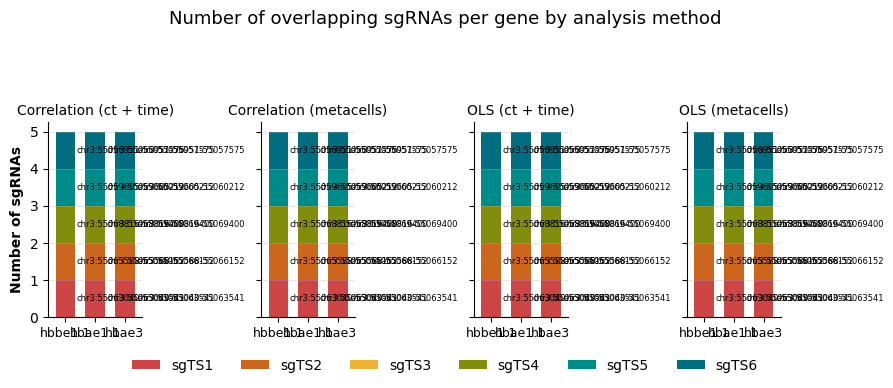

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

dfs = {
    "Correlation (ct + time)": cor_ctt,
    "Correlation (metacells)": cor_sc,
    "OLS (ct + time)":         ols_ctt,
    "OLS (metacells)":         ols_sc,
}

sg_order = ["sgTS1", "sgTS2", "sgTS3", "sgTS4", "sgTS5", "sgTS6"]
sg_colors = {
    "sgTS1": "#cd4545", "sgTS2": "#cd661d", "sgTS3": "#efb435",
    "sgTS4": "#828d0d", "sgTS5": "#008b8b", "sgTS6": "#006D80",
}

# Fixed gene order, set explicitly instead of derived from the data
all_genes = ["hbbe1.1", "hbae1.1", "hbae3"]

fig, axes = plt.subplots(1, 4, figsize=(9, 3), sharey=True)

for ax, (name, df) in zip(axes, dfs.items()):
    counts = (
        df.groupby(["gene", "sgRNA"]).size()
          .unstack(fill_value=0)
          .reindex(index=all_genes, columns=sg_order, fill_value=0)
    )

    counts.plot(
        kind="bar", stacked=True, ax=ax,
        color=[sg_colors[c] for c in counts.columns],
        width=0.65, legend=False,
    )

    x_offset = 0.38  # move labels slightly to the right of the bars

    # Annotate each stacked segment with its peak position
    for i, gene in enumerate(all_genes):
        bottom = 0
        for sg in sg_order:
            height = counts.loc[gene, sg] if gene in counts.index else 0
            if height > 0:
                match = df[(df["gene"] == gene) & (df["sgRNA"] == sg)]
                if not match.empty:
                    coord = match["peak_position"].iloc[0]
                    ax.text(
                        i + x_offset,
                        bottom + height / 2,
                        coord,
                        ha="left",
                        va="center",
                        fontsize=6,
                    )
            bottom += height

    ax.set_title(name, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("Number of sgRNAs" if ax is axes[0] else "", fontsize=10, fontweight="bold")
    ax.tick_params(axis="x", rotation=0, labelsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle="-", alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=6, bbox_to_anchor=(0.5, -0.1), frameon=False)
fig.suptitle("Number of overlapping sgRNAs per gene by analysis method", y=1.15, fontsize=13)

plt.tight_layout()
plt.savefig("sgrna_overlap_by_method.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
for i, gene in enumerate(all_genes):
        bottom = 0
        for sg in sg_order:
            height = counts.loc[gene, sg] if gene in counts.index else 0
            if height > 0:
                match = df[(df["gene"] == gene) & (df["sgRNA"] == sg)]
                if not match.empty:
                    coord = match["peak_position"].iloc[0]
                    ax.text(
                        i + x_offset,
                        bottom + height / 2,
                        coord,
                        ha="left",
                        va="center",
                        fontsize=6,
                    )
#print all coordinates of the peaks for each sgRNA and gene in the four dataframes
for name, df in dfs.items():
    print(f"\n{name}:")
    for gene in all_genes:
        for sg in sg_order:
            match = df[(df["gene"] == gene) & (df["sgRNA"] == sg)]
            if not match.empty:
                coords = match["peak_position"].tolist()
                print(f"{gene} - {sg}: {', '.join(coords)}")


Correlation (ct + time):
hbbe1.1 - sgTS1: chr3:55063040-55063541
hbbe1.1 - sgTS2: chr3:55065588-55066152
hbbe1.1 - sgTS4: chr3:55068816-55069400
hbbe1.1 - sgTS5: chr3:55059605-55060212
hbbe1.1 - sgTS6: chr3:55056951-55057575
hbae1.1 - sgTS1: chr3:55063040-55063541
hbae1.1 - sgTS2: chr3:55065588-55066152
hbae1.1 - sgTS4: chr3:55068816-55069400
hbae1.1 - sgTS5: chr3:55059605-55060212
hbae1.1 - sgTS6: chr3:55056951-55057575
hbae3 - sgTS1: chr3:55063040-55063541
hbae3 - sgTS2: chr3:55065588-55066152
hbae3 - sgTS4: chr3:55068816-55069400
hbae3 - sgTS5: chr3:55059605-55060212
hbae3 - sgTS6: chr3:55056951-55057575

Correlation (metacells):
hbbe1.1 - sgTS1: chr3:55063040-55063541
hbbe1.1 - sgTS2: chr3:55065588-55066152
hbbe1.1 - sgTS4: chr3:55068816-55069400
hbbe1.1 - sgTS5: chr3:55059605-55060212
hbbe1.1 - sgTS6: chr3:55056951-55057575
hbae1.1 - sgTS1: chr3:55063040-55063541
hbae1.1 - sgTS2: chr3:55065588-55066152
hbae1.1 - sgTS4: chr3:55068816-55069400
hbae1.1 - sgTS5: chr3:55059605-5506021

### STEP 9

In [26]:
import pandas as pd

#Correlation results
cor_res_100kb_ctt = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Results/gene_peak_correlation_ct_time_100kb_results.csv")
print(cor_res_100kb_ctt.head())
cor_100kb_df_sc = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Results/gene_peak_correlation_sc_100kb_results.csv")
print(cor_100kb_df_sc.head())


#OLS results
ols_res_df_ctt = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_res_all_windows_range_df_ct_time.csv")
ols_res_100kb_ctt = ols_res_df_ctt[ols_res_df_ctt["window"] == "100kb"].copy()
ols_res_100kb_ctt.head()


ols_res_df_sc = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_results_100kb_df_sc.csv")
ols_res_100kb_sc = ols_res_df_sc[ols_res_df_sc["window"] == "100kb"].copy()
ols_res_100kb_sc.head()

# classify every peak–gene pair into one of three categories
def classify_pair(row):
    if row["padj"] <= 0.05 and row["correlation"] < 0:
        return "sig. negative"
    elif row["padj"] <= 0.05 and row["correlation"] > 0:
        return "sig. positive"
    else:
        return "non-significant"

cor_res_100kb_ctt["category"] = cor_res_100kb_ctt.apply(classify_pair, axis=1)
cor_100kb_df_sc["category"] = cor_100kb_df_sc.apply(classify_pair, axis=1)    

  window  gene                peak  correlation    pvalue  neglog10_pvalue  \
0  100kb  a1cf  12-6186644-6187111     0.193512  0.006576         2.182015   
1  100kb  a1cf  12-6190483-6191143     0.135734  0.057840         1.237772   
2  100kb  a1cf  12-6225169-6226018     0.080739  0.260606         0.584015   
3  100kb  a1cf  12-6114452-6114950     0.125358  0.079997         1.096924   
4  100kb  a1cf  12-6140521-6140735     0.040975  0.568525         0.245251   

       padj  neglog10_padj  
0  0.034600       1.460927  
1  0.173677       0.760259  
2  0.472269       0.325810  
3  0.217494       0.662553  
4  0.748452       0.125836  
  window  gene                peak  correlation    pvalue  neglog10_pvalue  \
0  100kb  a1cf  12-6186644-6187111     0.121149  0.000016         4.791006   
1  100kb  a1cf  12-6190483-6191143     0.117048  0.000031         4.506702   
2  100kb  a1cf  12-6225169-6226018     0.061143  0.029989         1.523041   
3  100kb  a1cf  12-6114452-6114950     0.0603

In [27]:
#filter all four result by the three globin genes (hbbe1.1, hbae1.1, hbae3) 
globin_genes = ["hbbe1.1", "hbae1.1", "hbae3"]
cor_res_100kb_ctt_filtered = cor_res_100kb_ctt[cor_res_100kb_ctt["gene"].isin(globin_genes)]
cor_100kb_df_sc_filtered = cor_100kb_df_sc[cor_100kb_df_sc["gene"].isin(globin_genes)]
ols_res_100kb_ctt_filtered = ols_res_100kb_ctt[ols_res_100kb_ctt["gene"].isin(globin_genes)]
ols_res_100kb_sc_filtered = ols_res_100kb_sc[ols_res_100kb_sc["gene"].isin(globin_genes)]

In [56]:
print(cor_ctt_unique_peaks.head())
print(cor_sc_unique_peaks.head())
print(ols_ctt_unique_peaks.head())
print(ols_sc_unique_peaks.head())

   sgRNA  gene_chr  peak_start  peak_end     gene
0  sgTS1         3    55063040  55063541  hbae1.1
1  sgTS1         3    55063040  55063541    hbae3
2  sgTS1         3    55063040  55063541  hbbe1.1
3  sgTS2         3    55065588  55066152  hbae1.1
4  sgTS2         3    55065588  55066152    hbae3
   sgRNA  gene_chr  peak_start  peak_end     gene
0  sgTS1         3    55063040  55063541  hbae1.1
1  sgTS1         3    55063040  55063541    hbae3
2  sgTS1         3    55063040  55063541  hbbe1.1
3  sgTS2         3    55065588  55066152  hbae1.1
4  sgTS2         3    55065588  55066152    hbae3
   sgRNA  gene_chr  peak_start  peak_end     gene
0  sgTS1         3    55063040  55063541  hbae1.1
1  sgTS1         3    55063040  55063541    hbae3
2  sgTS1         3    55063040  55063541  hbbe1.1
3  sgTS2         3    55065588  55066152  hbae1.1
4  sgTS2         3    55065588  55066152    hbae3
   sgRNA  gene_chr  peak_start  peak_end     gene
0  sgTS1         3    55063040  55063541  hbae1.1


## COR & ct + time

In [22]:
#find the unique peaks in the cor_ctt_unique_peaks
cor_ctt_unique_peaks_df = cor_ctt_unique_peaks[["sgRNA","gene_chr", "peak_start", "peak_end", "gene"]].drop_duplicates().copy()
cor_ctt_unique_peaks_df["peak"] = cor_ctt_unique_peaks_df["gene_chr"].astype(str) + "-" + (cor_ctt_unique_peaks_df["peak_start"] + 1).astype(str) + "-" + cor_ctt_unique_peaks_df["peak_end"].astype(str)
cor_ctt_unique_peaks_df["sgRNA_overlap"] = True
cor_ctt_unique_peaks_df 

,sgRNA,gene_chr,peak_start,peak_end,gene,peak,sgRNA_overlap
0,sgTS1,3,55063040,55063541,hbae1.1,3-55063041-55063541,True
1,sgTS1,3,55063040,55063541,hbae3,3-55063041-55063541,True
2,sgTS1,3,55063040,55063541,hbbe1.1,3-55063041-55063541,True
3,sgTS2,3,55065588,55066152,hbae1.1,3-55065589-55066152,True
4,sgTS2,3,55065588,55066152,hbae3,3-55065589-55066152,True
5,sgTS2,3,55065588,55066152,hbbe1.1,3-55065589-55066152,True
6,sgTS4,3,55068816,55069400,hbae1.1,3-55068817-55069400,True
7,sgTS4,3,55068816,55069400,hbae3,3-55068817-55069400,True
8,sgTS4,3,55068816,55069400,hbbe1.1,3-55068817-55069400,True
9,sgTS5,3,55059605,55060212,hbae1.1,3-55059606-55060212,True


In [28]:
#find the unique peaks in the cor_res_100kb_ctt_filtered
val_cor_ctt_df = cor_res_100kb_ctt_filtered[cor_res_100kb_ctt_filtered["peak"].isin(cor_ctt_unique_peaks_df["peak"])].copy()
val_cor_ctt_df

,window,gene,peak,correlation,pvalue,neglog10_pvalue,padj,neglog10_padj,category
606231,100kb,hbae1.1,3-55056952-55057575,-0.435633,1.754019e-10,9.755966,9.098638e-09,8.041024,sig. negative
606242,100kb,hbae1.1,3-55059606-55060212,-0.100480,1.611314e-01,0.792820,3.475682e-01,0.458960,non-significant
606282,100kb,hbae1.1,3-55065589-55066152,0.068879,3.374208e-01,0.471828,5.533361e-01,0.257011,non-significant
606295,100kb,hbae1.1,3-55068817-55069400,-0.334141,1.698540e-06,5.769924,3.397793e-05,4.468803,sig. negative
606304,100kb,hbae1.1,3-55063041-55063541,-0.080142,2.641589e-01,0.578135,4.763114e-01,0.322109,non-significant
606446,100kb,hbae3,3-55056952-55057575,-0.408765,2.714304e-09,8.566341,1.089701e-07,6.962693,sig. negative
606460,100kb,hbae3,3-55059606-55060212,-0.085815,2.317205e-01,0.635036,4.388447e-01,0.357689,non-significant
606499,100kb,hbae3,3-55065589-55066152,0.075157,2.951233e-01,0.529997,5.099241e-01,0.292494,non-significant
606509,100kb,hbae3,3-55068817-55069400,-0.316154,6.356263e-06,5.196798,1.074544e-04,3.968776,sig. negative
606519,100kb,hbae3,3-55063041-55063541,-0.088111,2.194269e-01,0.658710,4.239679e-01,0.372667,non-significant


In [29]:
# add to cor_ctt_unique_peaks_df the category column from val_cor_ctt_df based on the peak column
cor_ctt_unique_peaks_df = cor_ctt_unique_peaks_df.merge(
    val_cor_ctt_df[["gene", "peak", "category"]]
        .drop_duplicates(["gene", "peak"]),
    on=["gene", "peak"],
    how="left"
)
cor_ctt_unique_peaks_df

,sgRNA,gene_chr,peak_start,peak_end,gene,peak,sgRNA_overlap,category
0,sgTS1,3,55063040,55063541,hbae1.1,3-55063041-55063541,True,non-significant
1,sgTS1,3,55063040,55063541,hbae3,3-55063041-55063541,True,non-significant
2,sgTS1,3,55063040,55063541,hbbe1.1,3-55063041-55063541,True,non-significant
3,sgTS2,3,55065588,55066152,hbae1.1,3-55065589-55066152,True,non-significant
4,sgTS2,3,55065588,55066152,hbae3,3-55065589-55066152,True,non-significant
5,sgTS2,3,55065588,55066152,hbbe1.1,3-55065589-55066152,True,non-significant
6,sgTS4,3,55068816,55069400,hbae1.1,3-55068817-55069400,True,sig. negative
7,sgTS4,3,55068816,55069400,hbae3,3-55068817-55069400,True,sig. negative
8,sgTS4,3,55068816,55069400,hbbe1.1,3-55068817-55069400,True,sig. negative
9,sgTS5,3,55059605,55060212,hbae1.1,3-55059606-55060212,True,non-significant


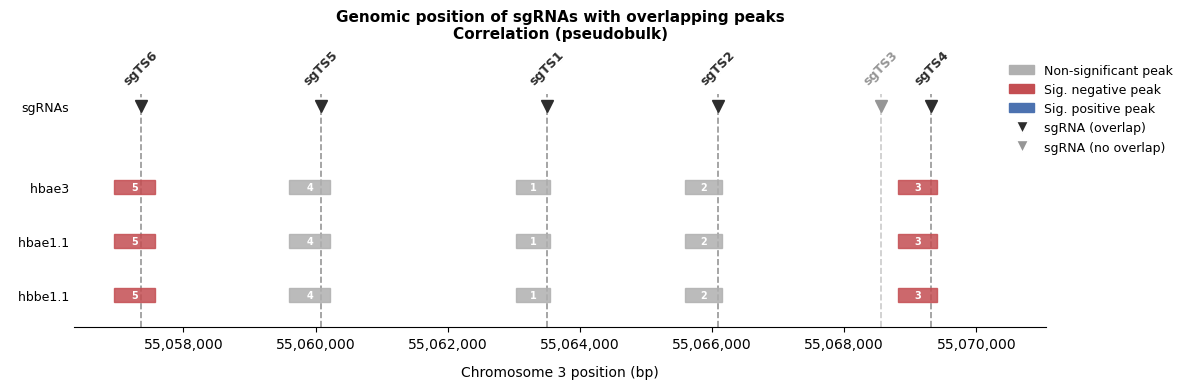

In [59]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import pandas as pd
import numpy as np


# ── Data ─────────────────────────────────────────────────────────────────────
sgRNA_coords = pd.DataFrame({
    "sgRNA":  ["sgTS1", "sgTS2", "sgTS3", "sgTS4", "sgTS5", "sgTS6"],
    "start":  [55063489, 55066076, 55068542, 55069310, 55060067, 55057348],
    "end":    [55063506, 55066093, 55068559, 55069327, 55060084, 55057365],
})
sgRNA_coords["mid"] = (sgRNA_coords["start"] + sgRNA_coords["end"]) / 2

# deduplicate peaks (same interval listed once per gene)
peaks_dedup = cor_ctt_unique_peaks_df.drop_duplicates(subset=["peak_start", "peak_end"]).copy()
peaks_dedup["mid"] = (peaks_dedup["peak_start"] + peaks_dedup["peak_end"]) / 2

# ── Colors ───────────────────────────────────────────────────────────────────
cat_colors = {
    "non-significant": "#b0b0b0",
    "sig. negative":   "#C44E52",
    "sig. positive":   "#4C72B0",
}
sgRNA_color      = "#2d2d2d"
no_overlap_color = "#969696"

# ── Layout: one track per gene + 1 sgRNA track ───────────────────────────────
genes    = [ "hbbe1.1", "hbae1.1", "hbae3"]
n_tracks = len(genes) + 1          # 3 gene tracks + 1 sgRNA track
track_h  = 0.25                    # height of peak rectangles
track_y  = {g: i for i, g in enumerate(genes)}   # hbae1.1=0, hbae3=1, hbbe1.1=2
sgRNA_track_y = len(genes) + 0.5  # sgRNA track sits above gene tracks

fig, ax = plt.subplots(figsize=(12, 4))
#white background without gridlines
ax.set_facecolor("white")
ax.grid(False)

# ── Draw peaks per gene track ─────────────────────────────────────────────────
for gene in genes:
    y = track_y[gene]
    gene_peaks = cor_ctt_unique_peaks_df[cor_ctt_unique_peaks_df["gene"] == gene].drop_duplicates(subset=["peak_start", "peak_end"]).reset_index(drop=True)
    for i, (_, row) in enumerate(gene_peaks.iterrows()):
        color = cat_colors.get(row["category"], "#b0b0b0")
        ax.add_patch(mpatches.Rectangle(
            (row["peak_start"], y - track_h / 2),
            row["peak_end"] - row["peak_start"],
            track_h,
            color=color, alpha=0.85, zorder=2
        ))

        mid = (row["peak_start"] + row["peak_end"]) / 2

        # peak number inside the rectangle
        ax.text(mid, y, str(i + 1),
                ha="center", va="center", fontsize=7,
                color="white", fontweight="bold", zorder=3)

# ── Draw sgRNA markers ────────────────────────────────────────────────────────
for _, row in sgRNA_coords.iterrows():
    overlaps = row["sgRNA"] in df["sgRNA"].values
    color    = sgRNA_color if overlaps else no_overlap_color
    mid      = row["mid"]

    # vertical line spanning all gene tracks + sgRNA track
    ax.axvline(mid, ymin=0, ymax=0.85, color=color,
               linewidth=1.2, linestyle="--", alpha=0.5, zorder=1)

    # single marker (no strand distinction)
    ax.plot(mid, sgRNA_track_y, marker="v",
            color=color, markersize=8, zorder=3)

    # label
    ax.text(mid, sgRNA_track_y + 0.35, row["sgRNA"],
            ha="center", va="bottom", fontsize=9, fontweight="bold", color=color, rotation= 45)

# ── Gene track labels (y-axis) ────────────────────────────────────────────────
ax.set_yticks(list(track_y.values()) + [sgRNA_track_y])
ax.set_yticklabels([f"  {g}" for g in genes] + ["sgRNAs"], fontsize=9, fontweight="roman")

# ── Axes formatting ───────────────────────────────────────────────────────────
x_min = sgRNA_coords.loc[sgRNA_coords["sgRNA"] == "sgTS6", "start"].values[0] - 1000
x_max = sgRNA_coords.loc[sgRNA_coords["sgRNA"] == "sgTS3", "end"].values[0] + 2500

ax.set_xlim(x_min, x_max)

all_coords = list(sgRNA_coords["start"]) + list(cor_ctt_unique_peaks_df["peak_start"]) + \
             list(sgRNA_coords["end"])   + list(cor_ctt_unique_peaks_df["peak_end"])
ax.set_ylim(-0.6, sgRNA_track_y + 1.0)
ax.set_xlabel("Chromosome 3 position (bp)", fontsize=10, fontweight="roman", labelpad=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.set_title("Genomic position of sgRNAs with overlapping peaks\nCorrelation (pseudobulk)",
             fontsize=11, fontweight="bold", pad=10)

# ── build peak position legend entries ───────────────────────────────────────
#peak_legend = []
#all_peaks = cor_ctt_unique_peaks_df.drop_duplicates(subset=["peak_start", "peak_end"]).reset_index(drop=True)
#for i, (_, row) in enumerate(all_peaks.iterrows()):
#    color = cat_colors.get(row["category"], "#b0b0b0")
#    peak_legend.append(
#        mpatches.Patch(color="none",
#                       label=f"Peak {i+1}: {int(row['peak_start']):,}–{int(row['peak_end']):,}")
#    )

legend_elements = [
    mpatches.Patch(color=cat_colors["non-significant"], label="Non-significant peak"),
    mpatches.Patch(color=cat_colors["sig. negative"],   label="Sig. negative peak"),
    mpatches.Patch(color=cat_colors["sig. positive"],   label="Sig. positive peak"),
    mlines.Line2D([0], [0], marker="v", color="w", markerfacecolor=sgRNA_color,
                  markersize=9, label="sgRNA (overlap)"),
    mlines.Line2D([0], [0], marker="v", color="w", markerfacecolor=no_overlap_color,
                  markersize=9, label="sgRNA (no overlap)"),
    mpatches.Patch(color="none", label=''),  # section header
] #+ peak_legend

ax.legend(handles=legend_elements, fontsize=9, frameon=False,
          loc="upper left", bbox_to_anchor=(0.95, 1))

plt.tight_layout()
plt.savefig("sgRNA_peak_overlap_plot.png", dpi=300)
plt.show()

## COR & sc

In [54]:
#find the unique peaks in the cor_sc_unique_peaks
cor_sc_unique_peaks_df = cor_sc_unique_peaks[["sgRNA","gene_chr", "peak_start", "peak_end", "gene"]].drop_duplicates().copy()
cor_sc_unique_peaks_df["peak"] = cor_sc_unique_peaks_df["gene_chr"].astype(str) + "-" + (cor_sc_unique_peaks_df["peak_start"] + 1).astype(str) + "-" + cor_sc_unique_peaks_df["peak_end"].astype(str)
cor_sc_unique_peaks_df["sgRNA_overlap"] = True
cor_sc_unique_peaks_df 

#find the unique peaks in the cor_res_100kb_sc_filtered
val_cor_sc_df = cor_100kb_df_sc_filtered[cor_100kb_df_sc_filtered["peak"].isin(cor_sc_unique_peaks_df["peak"])].copy()
val_cor_sc_df

# add to cor_sc_unique_peaks_df the category column from val_cor_sc_df based on the peak column
cor_sc_unique_peaks_df = cor_sc_unique_peaks_df.merge(
    val_cor_sc_df[["gene", "peak", "category"]]
        .drop_duplicates(["gene", "peak"]),
    on=["gene", "peak"],
    how="left"
)
cor_sc_unique_peaks_df

,sgRNA,gene_chr,peak_start,peak_end,gene,peak,sgRNA_overlap,category
0,sgTS1,3,55063040,55063541,hbae1.1,3-55063041-55063541,True,non-significant
1,sgTS1,3,55063040,55063541,hbae3,3-55063041-55063541,True,non-significant
2,sgTS1,3,55063040,55063541,hbbe1.1,3-55063041-55063541,True,non-significant
3,sgTS2,3,55065588,55066152,hbae1.1,3-55065589-55066152,True,sig. positive
4,sgTS2,3,55065588,55066152,hbae3,3-55065589-55066152,True,sig. positive
5,sgTS2,3,55065588,55066152,hbbe1.1,3-55065589-55066152,True,non-significant
6,sgTS4,3,55068816,55069400,hbae1.1,3-55068817-55069400,True,sig. positive
7,sgTS4,3,55068816,55069400,hbae3,3-55068817-55069400,True,sig. positive
8,sgTS4,3,55068816,55069400,hbbe1.1,3-55068817-55069400,True,sig. negative
9,sgTS5,3,55059605,55060212,hbae1.1,3-55059606-55060212,True,sig. positive


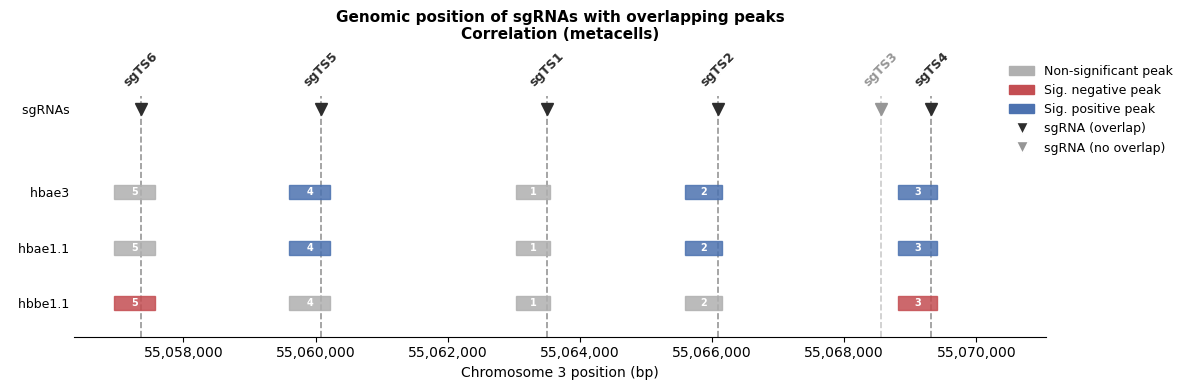

In [65]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import pandas as pd
import numpy as np

# ── Data ─────────────────────────────────────────────────────────────────────
sgRNA_coords = pd.DataFrame({
    "sgRNA":  ["sgTS1", "sgTS2", "sgTS3", "sgTS4", "sgTS5", "sgTS6"],
    "start":  [55063489, 55066076, 55068542, 55069310, 55060067, 55057348],
    "end":    [55063506, 55066093, 55068559, 55069327, 55060084, 55057365],
})
sgRNA_coords["mid"] = (sgRNA_coords["start"] + sgRNA_coords["end"]) / 2

# deduplicate peaks (same interval listed once per gene)
peaks_dedup = cor_sc_unique_peaks_df.drop_duplicates(subset=["peak_start", "peak_end"]).copy()
peaks_dedup["mid"] = (peaks_dedup["peak_start"] + peaks_dedup["peak_end"]) / 2

# ── Colors ───────────────────────────────────────────────────────────────────
cat_colors = {
    "non-significant": "#b0b0b0",
    "sig. negative":   "#C44E52",
    "sig. positive":   "#4C72B0",
}
sgRNA_color      = "#2d2d2d"
no_overlap_color = "#969696"

# ── Layout: one track per gene + 1 sgRNA track ───────────────────────────────
genes    = ["hbbe1.1", "hbae1.1", "hbae3"]
n_tracks = len(genes) + 1          # 3 gene tracks + 1 sgRNA track
track_h  = 0.25                    # height of peak rectangles
track_y  = {g: i for i, g in enumerate(genes)}   # hbae1.1=0, hbae3=1, hbbe1.1=2
sgRNA_track_y = len(genes) + 0.5  # sgRNA track sits above gene tracks

fig, ax = plt.subplots(figsize=(12, 4))

# ── Draw peaks per gene track ─────────────────────────────────────────────────
for gene in genes:
    y = track_y[gene]
    gene_peaks = cor_sc_unique_peaks_df[cor_sc_unique_peaks_df["gene"] == gene].drop_duplicates(subset=["peak_start", "peak_end"]).reset_index(drop=True)
    for i, (_, row) in enumerate(gene_peaks.iterrows()):
        color = cat_colors.get(row["category"], "#b0b0b0")
        ax.add_patch(mpatches.Rectangle(
            (row["peak_start"], y - track_h / 2),
            row["peak_end"] - row["peak_start"],
            track_h,
            color=color, alpha=0.85, zorder=2
        ))

        mid = (row["peak_start"] + row["peak_end"]) / 2

        # peak number inside the rectangle
        ax.text(mid, y, str(i + 1),
                ha="center", va="center", fontsize=7,
                color="white", fontweight="bold", zorder=3)

# ── Draw sgRNA markers ────────────────────────────────────────────────────────
for _, row in sgRNA_coords.iterrows():
    overlaps = row["sgRNA"] in df["sgRNA"].values
    color    = sgRNA_color if overlaps else no_overlap_color
    mid      = row["mid"]

    # vertical line spanning all gene tracks + sgRNA track
    ax.axvline(mid, ymin=0, ymax=0.85, color=color,
               linewidth=1.2, linestyle="--", alpha=0.5, zorder=1)

    # single marker (no strand distinction)
    ax.plot(mid, sgRNA_track_y, marker="v",
            color=color, markersize=8, zorder=3)

    # label
    ax.text(mid, sgRNA_track_y + 0.35, row["sgRNA"],
            ha="center", va="bottom", fontsize=9, fontweight="bold", color=color, rotation= 45)

# ── Gene track labels (y-axis) ────────────────────────────────────────────────
ax.set_yticks(list(track_y.values()) + [sgRNA_track_y])
ax.set_yticklabels([f"  {g}" for g in genes] + ["  sgRNAs"], fontsize=9)

# ── Axes formatting ───────────────────────────────────────────────────────────
x_min = sgRNA_coords.loc[sgRNA_coords["sgRNA"] == "sgTS6", "start"].values[0] - 1000
x_max = sgRNA_coords.loc[sgRNA_coords["sgRNA"] == "sgTS3", "end"].values[0] + 2500

ax.set_xlim(x_min, x_max)

all_coords = list(sgRNA_coords["start"]) + list(cor_sc_unique_peaks_df["peak_start"]) + \
             list(sgRNA_coords["end"])   + list(cor_sc_unique_peaks_df["peak_end"])
ax.set_ylim(-0.6, sgRNA_track_y + 1.0)
ax.set_xlabel("Chromosome 3 position (bp)", fontsize=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.set_title("Genomic position of sgRNAs with overlapping peaks\nCorrelation (metacells)",
             fontsize=11, fontweight="bold", pad=10)

# ── build peak position legend entries ───────────────────────────────────────
#peak_legend = []
#all_peaks = cor_sc_unique_peaks_df.drop_duplicates(subset=["peak_start", "peak_end"]).reset_index(drop=True)
#for i, (_, row) in enumerate(all_peaks.iterrows()):
#    color = cat_colors.get(row["category"], "#b0b0b0")
#    peak_legend.append(
#        mpatches.Patch(color="none",
#                       label=f"Peak {i+1}: {int(row['peak_start']):,}–{int(row['peak_end']):,}")
#    )

legend_elements = [
    mpatches.Patch(color=cat_colors["non-significant"], label="Non-significant peak"),
    mpatches.Patch(color=cat_colors["sig. negative"],   label="Sig. negative peak"),
    mpatches.Patch(color=cat_colors["sig. positive"],   label="Sig. positive peak"),
    mlines.Line2D([0], [0], marker="v", color="w", markerfacecolor=sgRNA_color,
                  markersize=9, label="sgRNA (overlap)"),
    mlines.Line2D([0], [0], marker="v", color="w", markerfacecolor=no_overlap_color,
                  markersize=9, label="sgRNA (no overlap)"),
    mpatches.Patch(color="none", label=''),  # section header
] #+ peak_legend


ax.legend(handles=legend_elements, fontsize=9, frameon=False,
          loc="upper left", bbox_to_anchor=(0.95, 1))

plt.tight_layout()
plt.savefig("sgRNA_peak_overlap_plot2.png", dpi=300)
plt.show()

## OLS & ct + time

In [60]:
#find the unique peaks in the cor_ctt_unique_peaks
ols_ctt_unique_peaks_df = ols_ctt_unique_peaks[["sgRNA","gene_chr", "peak_start", "peak_end", "gene"]].drop_duplicates().copy()
ols_ctt_unique_peaks_df["peak"] = ols_ctt_unique_peaks_df["gene_chr"].astype(str) + "-" + (ols_ctt_unique_peaks_df["peak_start"] + 1).astype(str) + "-" + ols_ctt_unique_peaks_df["peak_end"].astype(str)
ols_ctt_unique_peaks_df["sgRNA_overlap"] = True
ols_ctt_unique_peaks_df 

#find the unique peaks in the cor_res_100kb_ctt_filtered
val_ols_ctt_df = ols_res_100kb_ctt_filtered[ols_res_100kb_ctt_filtered["peak"].isin(ols_ctt_unique_peaks_df["peak"])].copy()
val_ols_ctt_df

# add to ols_ctt_unique_peaks_df the category column from val_ols_ctt_df based on the peak column
ols_ctt_unique_peaks_df = ols_ctt_unique_peaks_df.merge(
    val_ols_ctt_df[["gene", "peak", "category"]]
        .drop_duplicates(["gene", "peak"]),
    on=["gene", "peak"],
    how="left"
)
ols_ctt_unique_peaks_df

,sgRNA,gene_chr,peak_start,peak_end,gene,peak,sgRNA_overlap,category
0,sgTS1,3,55063040,55063541,hbae1.1,3-55063041-55063541,True,non-significant
1,sgTS1,3,55063040,55063541,hbae3,3-55063041-55063541,True,non-significant
2,sgTS1,3,55063040,55063541,hbbe1.1,3-55063041-55063541,True,non-significant
3,sgTS2,3,55065588,55066152,hbae1.1,3-55065589-55066152,True,non-significant
4,sgTS2,3,55065588,55066152,hbae3,3-55065589-55066152,True,non-significant
5,sgTS2,3,55065588,55066152,hbbe1.1,3-55065589-55066152,True,non-significant
6,sgTS4,3,55068816,55069400,hbae1.1,3-55068817-55069400,True,non-significant
7,sgTS4,3,55068816,55069400,hbae3,3-55068817-55069400,True,non-significant
8,sgTS4,3,55068816,55069400,hbbe1.1,3-55068817-55069400,True,non-significant
9,sgTS5,3,55059605,55060212,hbae1.1,3-55059606-55060212,True,non-significant


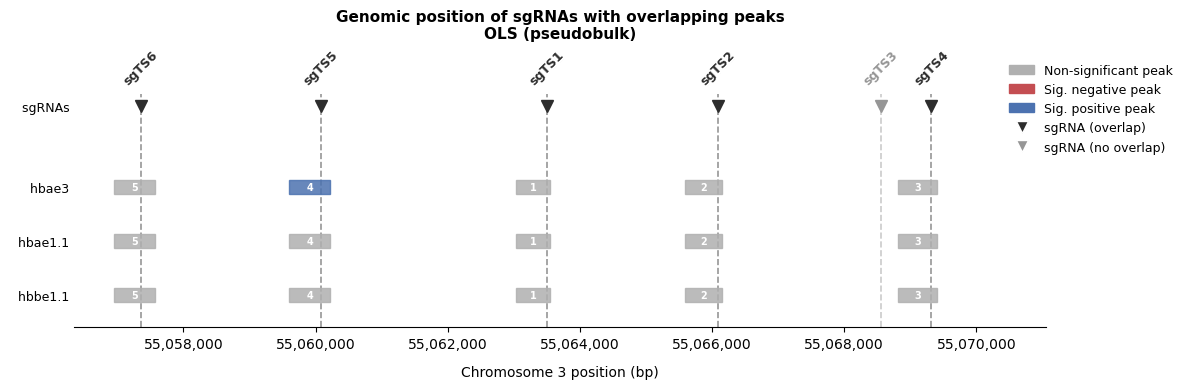

In [61]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import pandas as pd
import numpy as np

# ── Data ─────────────────────────────────────────────────────────────────────
sgRNA_coords = pd.DataFrame({
    "sgRNA":  ["sgTS1", "sgTS2", "sgTS3", "sgTS4", "sgTS5", "sgTS6"],
    "start":  [55063489, 55066076, 55068542, 55069310, 55060067, 55057348],
    "end":    [55063506, 55066093, 55068559, 55069327, 55060084, 55057365],
})
sgRNA_coords["mid"] = (sgRNA_coords["start"] + sgRNA_coords["end"]) / 2

# deduplicate peaks (same interval listed once per gene)
peaks_dedup = ols_ctt_unique_peaks_df.drop_duplicates(subset=["peak_start", "peak_end"]).copy()
peaks_dedup["mid"] = (peaks_dedup["peak_start"] + peaks_dedup["peak_end"]) / 2

# ── Colors ───────────────────────────────────────────────────────────────────
cat_colors = {
    "non-significant": "#b0b0b0",
    "sig. negative":   "#C44E52",
    "sig. positive":   "#4C72B0",
}
sgRNA_color      = "#2d2d2d"
no_overlap_color = "#969696"

# ── Layout: one track per gene + 1 sgRNA track ───────────────────────────────
genes    = ["hbbe1.1", "hbae1.1", "hbae3"]
n_tracks = len(genes) + 1          # 3 gene tracks + 1 sgRNA track
track_h  = 0.25                    # height of peak rectangles
track_y  = {g: i for i, g in enumerate(genes)}   # hbae1.1=0, hbae3=1, hbbe1.1=2
sgRNA_track_y = len(genes) + 0.5  # sgRNA track sits above gene tracks

fig, ax = plt.subplots(figsize=(12, 4))

# ── Draw peaks per gene track ─────────────────────────────────────────────────
for gene in genes:
    y = track_y[gene]
    gene_peaks = ols_ctt_unique_peaks_df[ols_ctt_unique_peaks_df["gene"] == gene].drop_duplicates(subset=["peak_start", "peak_end"]).reset_index(drop=True)
    for i, (_, row) in enumerate(gene_peaks.iterrows()):
        color = cat_colors.get(row["category"], "#b0b0b0")
        ax.add_patch(mpatches.Rectangle(
            (row["peak_start"], y - track_h / 2),
            row["peak_end"] - row["peak_start"],
            track_h,
            color=color, alpha=0.85, zorder=2
        ))

        mid = (row["peak_start"] + row["peak_end"]) / 2

        # peak number inside the rectangle
        ax.text(mid, y, str(i + 1),
                ha="center", va="center", fontsize=7,
                color="white", fontweight="bold", zorder=3)

# ── Draw sgRNA markers ────────────────────────────────────────────────────────
for _, row in sgRNA_coords.iterrows():
    overlaps = row["sgRNA"] in df["sgRNA"].values
    color    = sgRNA_color if overlaps else no_overlap_color
    mid      = row["mid"]

    # vertical line spanning all gene tracks + sgRNA track
    ax.axvline(mid, ymin=0, ymax=0.85, color=color,
               linewidth=1.2, linestyle="--", alpha=0.5, zorder=1)

    # single marker (no strand distinction)
    ax.plot(mid, sgRNA_track_y, marker="v",
            color=color, markersize=8, zorder=3)

    # label
    ax.text(mid, sgRNA_track_y + 0.35, row["sgRNA"],
            ha="center", va="bottom", fontsize=9, fontweight="bold", color=color, rotation= 45)

# ── Gene track labels (y-axis) ────────────────────────────────────────────────
ax.set_yticks(list(track_y.values()) + [sgRNA_track_y])
ax.set_yticklabels([f"  {g}" for g in genes] + ["  sgRNAs"], fontsize=9)

# ── Axes formatting ───────────────────────────────────────────────────────────
x_min = sgRNA_coords.loc[sgRNA_coords["sgRNA"] == "sgTS6", "start"].values[0] - 1000
x_max = sgRNA_coords.loc[sgRNA_coords["sgRNA"] == "sgTS3", "end"].values[0] + 2500

ax.set_xlim(x_min, x_max)

all_coords = list(sgRNA_coords["start"]) + list(ols_ctt_unique_peaks_df["peak_start"]) + \
             list(sgRNA_coords["end"])   + list(ols_ctt_unique_peaks_df["peak_end"])
ax.set_ylim(-0.6, sgRNA_track_y + 1.0)
ax.set_xlabel("Chromosome 3 position (bp)", fontsize=10, fontweight="roman", labelpad=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.set_title("Genomic position of sgRNAs with overlapping peaks\nOLS (pseudobulk)",
             fontsize=11, fontweight="bold", pad=10)

# ── build peak position legend entries ───────────────────────────────────────
#peak_legend = []
#all_peaks = ols_ctt_unique_peaks_df.drop_duplicates(subset=["peak_start", "peak_end"]).reset_index(drop=True)
#for i, (_, row) in enumerate(all_peaks.iterrows()):
#    color = cat_colors.get(row["category"], "#b0b0b0")
#    peak_legend.append(
#        mpatches.Patch(color="none",
#                       label=f"Peak {i+1}: {int(row['peak_start']):,}–{int(row['peak_end']):,}")
#    )

legend_elements = [
    mpatches.Patch(color=cat_colors["non-significant"], label="Non-significant peak"),
    mpatches.Patch(color=cat_colors["sig. negative"],   label="Sig. negative peak"),
    mpatches.Patch(color=cat_colors["sig. positive"],   label="Sig. positive peak"),
    mlines.Line2D([0], [0], marker="v", color="w", markerfacecolor=sgRNA_color,
                  markersize=9, label="sgRNA (overlap)"),
    mlines.Line2D([0], [0], marker="v", color="w", markerfacecolor=no_overlap_color,
                  markersize=9, label="sgRNA (no overlap)"),
    mpatches.Patch(color="none", label=''),  # section header
] #+ peak_legend

ax.legend(handles=legend_elements, fontsize=9, frameon=False,
          loc="upper left", bbox_to_anchor=(0.95, 1))

plt.tight_layout()
plt.savefig("sgRNA_peak_overlap_plot3.png", dpi=300)
plt.show()

## OLS & sc

In [62]:
#find the unique peaks in the cor_ctt_unique_peaks
ols_sc_unique_peaks_df = ols_sc_unique_peaks[["sgRNA","gene_chr", "peak_start", "peak_end", "gene"]].drop_duplicates().copy()
ols_sc_unique_peaks_df["peak"] = ols_sc_unique_peaks_df["gene_chr"].astype(str) + "-" + (ols_sc_unique_peaks_df["peak_start"] + 1).astype(str) + "-" + ols_sc_unique_peaks_df["peak_end"].astype(str)
ols_sc_unique_peaks_df["sgRNA_overlap"] = True
ols_sc_unique_peaks_df 

#find the unique peaks in the cor_res_100kb_ctt_filtered
val_ols_sc_df = ols_res_100kb_sc_filtered[ols_res_100kb_sc_filtered["peak"].isin(ols_sc_unique_peaks_df["peak"])].copy()
val_ols_sc_df

# add to ols_sc_unique_peaks_df the category column from val_ols_sc_df based on the peak column
ols_sc_unique_peaks_df = ols_sc_unique_peaks_df.merge(
    val_ols_sc_df[["gene", "peak", "category"]]
        .drop_duplicates(["gene", "peak"]),
    on=["gene", "peak"],
    how="left"
)
ols_sc_unique_peaks_df

,sgRNA,gene_chr,peak_start,peak_end,gene,peak,sgRNA_overlap,category
0,sgTS1,3,55063040,55063541,hbae1.1,3-55063041-55063541,True,non-significant
1,sgTS1,3,55063040,55063541,hbae3,3-55063041-55063541,True,non-significant
2,sgTS1,3,55063040,55063541,hbbe1.1,3-55063041-55063541,True,non-significant
3,sgTS2,3,55065588,55066152,hbae1.1,3-55065589-55066152,True,non-significant
4,sgTS2,3,55065588,55066152,hbae3,3-55065589-55066152,True,non-significant
5,sgTS2,3,55065588,55066152,hbbe1.1,3-55065589-55066152,True,non-significant
6,sgTS4,3,55068816,55069400,hbae1.1,3-55068817-55069400,True,non-significant
7,sgTS4,3,55068816,55069400,hbae3,3-55068817-55069400,True,non-significant
8,sgTS4,3,55068816,55069400,hbbe1.1,3-55068817-55069400,True,non-significant
9,sgTS5,3,55059605,55060212,hbae1.1,3-55059606-55060212,True,non-significant


In [133]:
print(ols_sc_unique_peaks_df.shape)
print(ols_sc_unique_peaks_df.head(10).to_string())
print(ols_sc_unique_peaks_df["category"].unique())
print(ols_sc_unique_peaks_df["sgRNA_overlap"].unique())
print(ols_sc_unique_peaks_df["gene"].unique())

(15, 8)
   sgRNA  gene_chr  peak_start  peak_end     gene                 peak  sgRNA_overlap         category
0  sgTS1         3    55063040  55063541  hbae1.1  3-55063041-55063541           True  non-significant
1  sgTS1         3    55063040  55063541    hbae3  3-55063041-55063541           True  non-significant
2  sgTS1         3    55063040  55063541  hbbe1.1  3-55063041-55063541           True  non-significant
3  sgTS2         3    55065588  55066152  hbae1.1  3-55065589-55066152           True  non-significant
4  sgTS2         3    55065588  55066152    hbae3  3-55065589-55066152           True  non-significant
5  sgTS2         3    55065588  55066152  hbbe1.1  3-55065589-55066152           True  non-significant
6  sgTS4         3    55068816  55069400  hbae1.1  3-55068817-55069400           True  non-significant
7  sgTS4         3    55068816  55069400    hbae3  3-55068817-55069400           True  non-significant
8  sgTS4         3    55068816  55069400  hbbe1.1  3-55068817-550

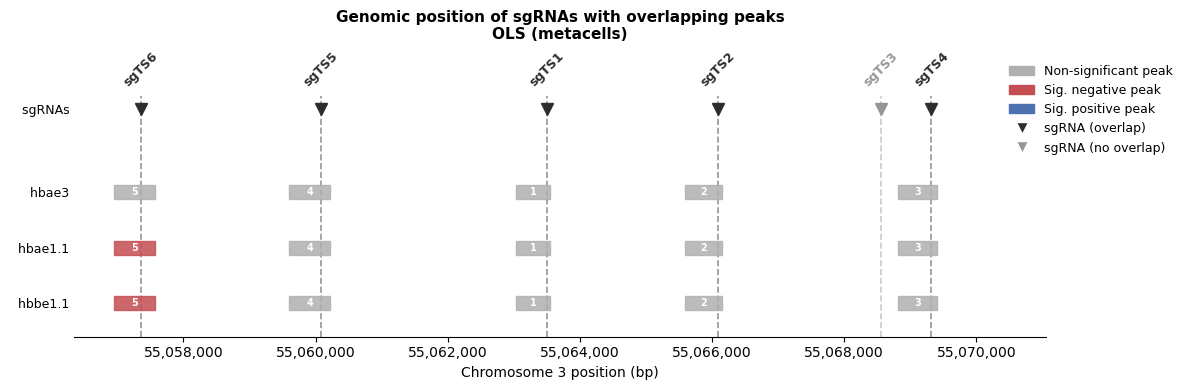

In [64]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import pandas as pd
import numpy as np

# ── Data ─────────────────────────────────────────────────────────────────────
sgRNA_coords = pd.DataFrame({
    "sgRNA":  ["sgTS1", "sgTS2", "sgTS3", "sgTS4", "sgTS5", "sgTS6"],
    "start":  [55063489, 55066076, 55068542, 55069310, 55060067, 55057348],
    "end":    [55063506, 55066093, 55068559, 55069327, 55060084, 55057365],
})
sgRNA_coords["mid"] = (sgRNA_coords["start"] + sgRNA_coords["end"]) / 2

# deduplicate peaks (same interval listed once per gene)
peaks_dedup = ols_sc_unique_peaks_df.drop_duplicates(subset=["peak_start", "peak_end"]).copy()
peaks_dedup["mid"] = (peaks_dedup["peak_start"] + peaks_dedup["peak_end"]) / 2

# ── Colors ───────────────────────────────────────────────────────────────────
cat_colors = {
    "non-significant": "#b0b0b0",
    "sig. negative":   "#C44E52",
    "sig. positive":   "#4C72B0",
}
sgRNA_color      = "#2d2d2d"
no_overlap_color = "#969696"

# ── Layout: one track per gene + 1 sgRNA track ───────────────────────────────
genes    = ["hbbe1.1", "hbae1.1", "hbae3"]
n_tracks = len(genes) + 1          # 3 gene tracks + 1 sgRNA track
track_h  = 0.25                    # height of peak rectangles
track_y  = {g: i for i, g in enumerate(genes)}   # hbae1.1=0, hbae3=1, hbbe1.1=2
sgRNA_track_y = len(genes) + 0.5  # sgRNA track sits above gene tracks

fig, ax = plt.subplots(figsize=(12, 4))

# ── Draw peaks per gene track ─────────────────────────────────────────────────
for gene in genes:
    y = track_y[gene]
    gene_peaks = ols_sc_unique_peaks_df[ols_sc_unique_peaks_df["gene"] == gene].drop_duplicates(subset=["peak_start", "peak_end"]).reset_index(drop=True)
    for i, (_, row) in enumerate(gene_peaks.iterrows()):
        color = cat_colors.get(row["category"], "#b0b0b0")
        ax.add_patch(mpatches.Rectangle(
            (row["peak_start"], y - track_h / 2),
            row["peak_end"] - row["peak_start"],
            track_h,
            color=color, alpha=0.85, zorder=2
        ))

        mid = (row["peak_start"] + row["peak_end"]) / 2

        # peak number inside the rectangle
        ax.text(mid, y, str(i + 1),
                ha="center", va="center", fontsize=7,
                color="white", fontweight="bold", zorder=3)

# ── Draw sgRNA markers ────────────────────────────────────────────────────────
for _, row in sgRNA_coords.iterrows():
    overlaps = row["sgRNA"] in df["sgRNA"].values
    color    = sgRNA_color if overlaps else no_overlap_color
    mid      = row["mid"]

    # vertical line spanning all gene tracks + sgRNA track
    ax.axvline(mid, ymin=0, ymax=0.85, color=color,
               linewidth=1.2, linestyle="--", alpha=0.5, zorder=1)

    # single marker (no strand distinction)
    ax.plot(mid, sgRNA_track_y, marker="v",
            color=color, markersize=8, zorder=3)

    # label
    ax.text(mid, sgRNA_track_y + 0.35, row["sgRNA"],
            ha="center", va="bottom", fontsize=9, fontweight="bold", color=color, rotation= 45)

# ── Gene track labels (y-axis) ────────────────────────────────────────────────
ax.set_yticks(list(track_y.values()) + [sgRNA_track_y])
ax.set_yticklabels([f"  {g}" for g in genes] + ["  sgRNAs"], fontsize=9)

# ── Axes formatting ───────────────────────────────────────────────────────────
x_min = sgRNA_coords.loc[sgRNA_coords["sgRNA"] == "sgTS6", "start"].values[0] - 1000
x_max = sgRNA_coords.loc[sgRNA_coords["sgRNA"] == "sgTS3", "end"].values[0] + 2500

ax.set_xlim(x_min, x_max)

all_coords = list(sgRNA_coords["start"]) + list(ols_sc_unique_peaks_df["peak_start"]) + \
             list(sgRNA_coords["end"])   + list(ols_sc_unique_peaks_df["peak_end"])
ax.set_ylim(-0.6, sgRNA_track_y + 1.0)
ax.set_xlabel("Chromosome 3 position (bp)", fontsize=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.set_title("Genomic position of sgRNAs with overlapping peaks\nOLS (metacells)",
             fontsize=11, fontweight="bold", pad=10)

# ── build peak position legend entries ───────────────────────────────────────
#peak_legend = []
#all_peaks = ols_sc_unique_peaks_df.drop_duplicates(subset=["peak_start", "peak_end"]).reset_index(drop=True)
#for i, (_, row) in enumerate(all_peaks.iterrows()):
#    color = cat_colors.get(row["category"], "#b0b0b0")
#    peak_legend.append(
#        mpatches.Patch(color="none",
#                       label=f"Peak {i+1}: {int(row['peak_start']):,}–{int(row['peak_end']):,}")
#    )

legend_elements = [
    mpatches.Patch(color=cat_colors["non-significant"], label="Non-significant peak"),
    mpatches.Patch(color=cat_colors["sig. negative"],   label="Sig. negative peak"),
    mpatches.Patch(color=cat_colors["sig. positive"],   label="Sig. positive peak"),
    mlines.Line2D([0], [0], marker="v", color="w", markerfacecolor=sgRNA_color,
                  markersize=9, label="sgRNA (overlap)"),
    mlines.Line2D([0], [0], marker="v", color="w", markerfacecolor=no_overlap_color,
                  markersize=9, label="sgRNA (no overlap)"),
    mpatches.Patch(color="none", label=''),  # section header
] #+ peak_legend

ax.legend(handles=legend_elements, fontsize=9, frameon=False,
          loc="upper left", bbox_to_anchor=(0.95, 1))

plt.tight_layout()
plt.savefig("sgRNA_peak_overlap_plot4.png", dpi=300)
plt.show()